In [ ]:
# ── [안티그래비티 자체 실행 독립화 설정] ──────────────────────────
# 이 셀은 외부 파일(config/*, src/*)의 의존성을 가로채어
# 이 노트북 내에서 모든 동작이 완결되도록 합니다.
from __future__ import annotations
import sys
import types

# 1. 패키지 및 가상 모듈 등록
for pkg in ['config', 'src', 'config.path_utils']:
    if pkg not in sys.modules:
        sys.modules[pkg] = types.ModuleType(pkg)

# 2. config.path_utils 인라인 구현 등록
path_utils_dict = {}
exec(r'''
import os
from pathlib import Path

PROJECT_ROOT = Path(os.path.abspath(os.path.join(os.getcwd(), "..")))
DATA_ROOT = Path(os.environ.get("ML_HDD_DATA_DIR", PROJECT_ROOT / "data2")).expanduser()
FE_SPLIT_REL = "03_splitting"

def data_path(relative_path: str) -> str:
    return str(DATA_ROOT / relative_path)

def fe_data_path(filename: str) -> str:
    return data_path(f"{FE_SPLIT_REL}/{filename}")

def validate_path_contract(paths: list[tuple[str, str, str]]) -> None:
    print("\n[Data Path Contract]")
    missing = []
    for label, kind, path_str in paths:
        path = Path(path_str)
        if kind == "dir":
            exists = path.is_dir()
        elif kind == "file":
            exists = path.is_file()
        else:
            raise ValueError(f"Unknown path kind: {kind}")
        status = "OK" if exists else "MISSING"
        size = f" ({path.stat().st_size:,} bytes)" if exists and path.is_file() else ""
        print(f"  [{status}] {label}: {path}{size}")
        if not exists:
            missing.append(f"- {label}: {path}")
    if missing:
        raise FileNotFoundError(
            "Required data paths are missing. Refusing to continue with a partial "
            "or mismatched dataset.\n" + "\n".join(missing)
        )

def val_calib_missing_hint(val_calib_path: str | Path) -> str:
    calib = Path(val_calib_path)
    raw = DATA_ROOT / FE_SPLIT_REL / "val_calib_raw.parquet"
    lines = [f"Missing: {calib}"]
    if raw.is_file():
        lines.append(
            "Found val_calib_raw.parquet — run notebooks/06a_feature_engineering.ipynb "
            "to create val_calib.parquet."
        )
    else:
        lines.append(
            "Also missing val_calib_raw.parquet — place split files under "
            f"{DATA_ROOT / FE_SPLIT_REL} (see README 데이터 분할 후), "
            "then run notebooks/03_data_splitting.ipynb and "
            "notebooks/06a_feature_engineering.ipynb."
        )
    return "\n".join(lines)
''', path_utils_dict, path_utils_dict)
for k, v in path_utils_dict.items():
    if not k.startswith('__'):
        setattr(sys.modules['config.path_utils'], k, v)

# Helper variables in outer scope
PROJECT_ROOT = sys.modules['config.path_utils'].PROJECT_ROOT
DATA_ROOT = sys.modules['config.path_utils'].DATA_ROOT
FE_SPLIT_REL = sys.modules['config.path_utils'].FE_SPLIT_REL
data_path = sys.modules['config.path_utils'].data_path
fe_data_path = sys.modules['config.path_utils'].fe_data_path
validate_path_contract = sys.modules['config.path_utils'].validate_path_contract
val_calib_missing_hint = sys.modules['config.path_utils'].val_calib_missing_hint

# ── config.final_eval_config 인라인 등록 ──
if 'config.final_eval_config' not in sys.modules:
    sys.modules['config.final_eval_config'] = types.ModuleType('config.final_eval_config')
cfg_dict = {
    'PROJECT_ROOT': PROJECT_ROOT,
    'DATA_ROOT': DATA_ROOT,
    'FE_SPLIT_REL': FE_SPLIT_REL,
    'data_path': data_path,
    'fe_data_path': fe_data_path,
    'validate_path_contract': validate_path_contract,
    'val_calib_missing_hint': val_calib_missing_hint,
}
exec(r'''"""
final_eval_config.py  ─  최종 모델 평가 설정  (README §8)
──────────────────────────────────────────────────────────
08_final_evaluation.ipynb 전용. 설정값은 여기서만 관리합니다.
"""

# from config.path_utils import PROJECT_ROOT, fe_data_path

_BASE = PROJECT_ROOT

# ── 학습 산출물 (06c + 07에서 저장된 앙상블·임계값) ─────────
MODEL_SAVE_DIR = str(_BASE / "models2" / "06d_optuna_tuning" / "underbagging_ensemble_4")
N_SUBSETS = 10  # subset_*.pkl 개수 (06c SAMPLER_KWARGS.n_subsets 와 일치)

# ── 입력 경로 ────────────────────────────────────────────────
TEST_PATH = fe_data_path("test_with_failure_date.parquet")
# TEST_PATH = fe_data_path("test.parquet")

REQUIRED_DATA_PATHS = [
    ("model save directory", "dir", MODEL_SAVE_DIR),
    ("best threshold metadata", "file", f"{MODEL_SAVE_DIR}/best_threshold.json"),
    ("test feature data", "file", TEST_PATH),
]

# ── 최적 임계값 수동 오버라이드 (Optional) ─────────────────────
# 값을 지정하지 않으면 (None), 모델 폴더 내 best_threshold.json 에서 자동으로 불러옵니다.
MANUAL_BEST_T = 0.9261    
MANUAL_BEST_N = 2

# ── 컬럼명 ───────────────────────────────────────────────────
TARGET_COL = "failure"
SERIAL_COL = "serial_number"
DATE_COL   = "date"

ALARM_WINDOW = 14  # 알람 탐지 슬라이딩 윈도우 크기 (일 단위)

''', cfg_dict, cfg_dict)
for k, v in cfg_dict.items():
    if not k.startswith('__'):
        setattr(sys.modules['config.final_eval_config'], k, v)

# ── src.eval_core 인라인 등록 ──
if 'src.eval_core' not in sys.modules:
    sys.modules['src.eval_core'] = types.ModuleType('src.eval_core')
old_keys = set(globals().keys())
exec(r'''"""
eval_core.py  ─  임계값 튜닝 + 모델 평가 엔진  (README §7, §8)
──────────────────────────────────────────────────────────────
§7  ThresholdTuner      : val_calib 그리드서치 → FPR별 Recall 표 → FPR–Recall 곡선
§8.1 evaluate_row_level : 행 단위 PR-AUC / MCC / F1 평가
§8.2 EntityLevelEvaluator : 개체 단위 롤링 평가 (Hit/Miss/FA + Lead Time)

설정은 config/threshold_config.py, config/final_eval_config.py 에서만.
"""

from __future__ import annotations

import time
import warnings
from typing import Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    matthews_corrcoef,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

warnings.filterwarnings("ignore")


# ── 한글 폰트 ────────────────────────────────────────────────
def _set_korean_font():
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

_set_korean_font()

SEP = "=" * 65


def _log(msg: str, *, indent: int = 0) -> None:
    prefix = "  " * indent
    print(f"{prefix}{msg}", flush=True)


def _log_step(step: str, detail: str = "") -> None:
    line = f"[§7] {step}"
    if detail:
        line += f" — {detail}"
    _log(line)


def save_threshold_tuning_csvs(
    tuner: "ThresholdTuner",
    cfg,
    out_dir,
) -> dict[str, str]:
    """§7 튜닝 결과를 CSV로 저장. 반환: {fpr_recall_table, threshold_grid} 경로."""
    from pathlib import Path

    if tuner._result is None or tuner._grid_df is None:
        raise RuntimeError("ThresholdTuner.fit() 이후에만 CSV 저장 가능합니다.")

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    table_name = getattr(cfg, "FPR_RECALL_TABLE_CSV", "fpr_recall_table.csv")
    grid_name = getattr(cfg, "THRESHOLD_GRID_CSV", "threshold_grid.csv")

    table_rows = tuner._result["fpr_recall_table"]
    df_table = pd.DataFrame(table_rows)
    df_table.insert(0, "fpr_cap_pct", (df_table["fpr_cap"] * 100).round(3))
    df_table["fpr_actual_pct"] = (df_table["fpr_actual"] * 100).round(4)
    df_table["recall_pct"] = (df_table["recall"] * 100).round(4)

    path_table = out_dir / table_name
    path_grid = out_dir / grid_name
    df_table.to_csv(path_table, index=False, encoding="utf-8-sig")
    tuner._grid_df.to_csv(path_grid, index=False, encoding="utf-8-sig")

    return {
        "fpr_recall_table": str(path_table),
        "threshold_grid": str(path_grid),
    }


# ════════════════════════════════════════════════════════════
#  §7.  THRESHOLD TUNER
#  val_calib 에서 그리드서치 → FPR 상한 내 Recall 최대화
# ════════════════════════════════════════════════════════════

def summarize_recall_at_fpr_levels(
    grid_df: pd.DataFrame,
    fpr_levels: list[float],
    *,
    operating_fpr: float | None = None,
) -> list[dict]:
    """각 FPR 상한에서 Recall을 최대화한 운영점 요약 (README §7 간판 표)."""
    rows = []
    for cap in fpr_levels:
        valid = grid_df[grid_df["fpr"] <= cap]
        if len(valid) == 0:
            best_row = grid_df.loc[grid_df["fpr"].idxmin()]
        else:
            best_row = valid.loc[valid["recall"].idxmax()]

        rows.append({
            "fpr_cap": cap,
            "recall": float(best_row["recall"]),
            "fpr_actual": float(best_row["fpr"]),
            "precision": float(best_row["precision"]),
            "f1": float(best_row["f1"]),
            "threshold": float(best_row["threshold"]),
            "is_save_point": operating_fpr is not None and cap == operating_fpr,
        })
    return rows


class ThresholdTuner:
    """
    val_calib 그리드서치 후 FPR 상한별 Recall 표를 출력하고 FPR–Recall 곡선을 그림.

    Parameters
    ----------
    fpr_levels            : README §7 간판 표에 쓸 FPR 상한 목록 (필수)
    n_grid                : 임계값 탐색 격자 수
    save_operating_fpr_cap: 08 저장용으로 표에서 선택할 FPR 상한 (예: 0.01). None이면 미선택
    """

    def __init__(
        self,
        fpr_levels: list[float],
        n_grid: int = 1000,
        save_operating_fpr_cap: float | None = None,
    ):
        if not fpr_levels:
            raise ValueError("fpr_levels must be a non-empty list (e.g. [0.001, 0.005, 0.01, 0.05])")
        self.fpr_levels = list(fpr_levels)
        self.n_grid = n_grid
        self.save_operating_fpr_cap = save_operating_fpr_cap
        self._result: Optional[dict] = None
        self._grid_df: Optional[pd.DataFrame] = None

    # ----------------------------------------------------------
    def fit(self, y_true: np.ndarray, y_prob: np.ndarray) -> dict:
        """
        val_calib 데이터로 최적 임계값 탐색.

        Returns
        -------
        dict: threshold, recall, fpr, precision, f1, pr_auc, fpr_recall_table
        """
        y_true = np.asarray(y_true)
        n_pos  = int(y_true.sum())
        n_neg  = int((y_true == 0).sum())
        n_rows = len(y_true)

        thresholds = np.linspace(0.0, 1.0, self.n_grid + 1)
        n_thr = len(thresholds)
        _log(
            f"임계값 그리드 서치: {n_thr:,}개 후보 × {n_rows:,}행 "
            f"(FPR 표: {[f'{c*100:.1f}%' for c in self.fpr_levels]})",
            indent=1,
        )
        t_grid = time.perf_counter()

        records = []
        for i, thr in enumerate(thresholds):
            y_pred = (y_prob >= thr).astype(int)
            tp = int(((y_pred == 1) & (y_true == 1)).sum())
            fp = int(((y_pred == 1) & (y_true == 0)).sum())
            fn = int(((y_pred == 0) & (y_true == 1)).sum())
            tn = int(((y_pred == 0) & (y_true == 0)).sum())

            recall    = tp / n_pos if n_pos > 0 else 0.0
            fpr       = fp / n_neg if n_neg > 0 else 0.0
            precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
            f1        = (2 * precision * recall / (precision + recall)
                         if (precision + recall) > 0 else 0.0)

            records.append(dict(threshold=thr, recall=recall, fpr=fpr,
                                precision=precision, f1=f1,
                                tp=tp, fp=fp, fn=fn, tn=tn))

            if i == 0 or i == n_thr - 1 or (i + 1) % 250 == 0:
                elapsed = time.perf_counter() - t_grid
                pct = 100.0 * (i + 1) / n_thr
                _log(f"... {i + 1:,}/{n_thr:,} ({pct:.0f}%) — {elapsed:.1f}s 경과", indent=2)

        _log(f"그리드 서치 완료 ({time.perf_counter() - t_grid:.1f}s)", indent=1)

        self._grid_df = pd.DataFrame(records)
        _log("PR-AUC 계산 중...", indent=1)
        pr_auc = average_precision_score(y_true, y_prob)
        _log("FPR별 Recall 표 집계 중...", indent=1)

        fpr_recall_table = summarize_recall_at_fpr_levels(
            self._grid_df,
            self.fpr_levels,
            operating_fpr=self.save_operating_fpr_cap,
        )

        save_row = None
        if self.save_operating_fpr_cap is not None:
            save_row = next(
                (r for r in fpr_recall_table if r["fpr_cap"] == self.save_operating_fpr_cap),
                None,
            )
            if save_row is None:
                raise ValueError(
                    f"save_operating_fpr_cap={self.save_operating_fpr_cap} not in fpr_levels"
                )

        self._result = dict(
            threshold=float(save_row["threshold"]) if save_row else None,
            recall=float(save_row["recall"]) if save_row else None,
            fpr=float(save_row["fpr_actual"]) if save_row else None,
            precision=float(save_row["precision"]) if save_row else None,
            f1=float(save_row["f1"]) if save_row else None,
            pr_auc=float(pr_auc),
            save_operating_fpr_cap=self.save_operating_fpr_cap,
            fpr_recall_table=fpr_recall_table,
            n_pos=n_pos,
            n_neg=n_neg,
        )

        self.print_table()
        return self._result

    # ----------------------------------------------------------
    def print_table(self) -> None:
        """README §7 간판 표 (FPR 상한별 Recall) — 그래프보다 먼저 출력."""
        if self._result is None:
            raise RuntimeError("fit() 을 먼저 호출하세요.")
        r = self._result
        table = r["fpr_recall_table"]

        print(SEP)
        print("  THRESHOLD TUNING — val_calib (README §7)")
        print(SEP)
        print(f"  PR-AUC (확률 품질, 임계값 무관): {r['pr_auc']:.5f}")
        print(f"  표본: 고장 {r['n_pos']:,}행 / 정상 {r['n_neg']:,}행\n")

        print("  [FPR 상한별 최대 Recall — 간판 표]")
        print(f"  {'FPR 상한':>10}  {'Recall':>10}  {'실제 FPR':>10}  {'threshold':>10}")
        print(f"  {'-'*10}  {'-'*10}  {'-'*10}  {'-'*10}")
        for row in table:
            cap_pct = row["fpr_cap"] * 100
            rec_pct = row["recall"] * 100
            fpr_pct = row["fpr_actual"] * 100
            tag = " ← 08 저장" if row.get("is_save_point") else ""
            print(
                f"  {cap_pct:>9.1f}%  {rec_pct:>9.2f}%  {fpr_pct:>9.2f}%  {row['threshold']:>10.4f}{tag}"
            )
            print(f"      → FPR {fpr_pct:.2f}%에서 Recall {rec_pct:.2f}%")

        if r.get("threshold") is not None and r.get("save_operating_fpr_cap") is not None:
            cap = r["save_operating_fpr_cap"] * 100
            print(
                f"\n  [08 저장용] FPR 상한 {cap:.1f}% 행 → threshold = {r['threshold']:.4f}"
            )
        print(SEP)

    # ----------------------------------------------------------
    def plot(self):
        """README §7: FPR(x)–Recall(y) 곡선 (표의 각 운영점 표시). fit()·print_table() 이후 호출."""
        if self._grid_df is None:
            raise RuntimeError("fit() 을 먼저 호출하세요.")

        gdf = self._grid_df
        table = self._result["fpr_recall_table"]

        fig, ax = plt.subplots(figsize=(8, 6))
        ax.plot(gdf["fpr"], gdf["recall"], color="purple", lw=2, label="FPR–Recall curve")
        for row in table:
            ax.scatter(
                row["fpr_actual"],
                row["recall"],
                s=100,
                zorder=5,
                label=f"FPR≤{row['fpr_cap']*100:.1f}%",
            )
            ax.annotate(
                f"{row['fpr_cap']*100:.1f}%\nR={row['recall']:.2f}",
                (row["fpr_actual"], row["recall"]),
                textcoords="offset points",
                xytext=(6, 6),
                fontsize=9,
            )
        ax.set_xlabel("FPR (오탐율)")
        ax.set_ylabel("Recall (탐지율, TPR)")
        ax.set_title("Recall vs FPR (val_calib)", fontweight="bold")
        ax.legend(loc="lower right", fontsize=8)
        ax.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    @property
    def best_threshold(self) -> float:
        if self._result is None:
            raise RuntimeError("fit() 을 먼저 호출하세요.")
        thr = self._result.get("threshold")
        if thr is None:
            raise RuntimeError(
                "저장용 threshold 없음. threshold_config.SAVE_OPERATING_FPR_CAP 을 설정하세요."
            )
        return float(thr)


# ════════════════════════════════════════════════════════════
#  §8.1  ROW-LEVEL EVALUATION
#  PR-AUC / MCC / F1 / Precision / Recall / FPR
# ════════════════════════════════════════════════════════════

def evaluate_row_level(
    y_true: np.ndarray,
    y_prob: np.ndarray,
    threshold: float,
    title: str = "Test Set",
) -> dict:
    """
    README §8.1 행 단위 점수 평가.

    평가 지표: PR-AUC, MCC, F1, Precision, Recall, FPR
    시각화  : PR Curve + Confusion Matrix
    """
    y_true = np.asarray(y_true)
    y_pred = (y_prob >= threshold).astype(int)

    pr_auc = average_precision_score(y_true, y_prob)
    mcc    = matthews_corrcoef(y_true, y_pred)
    f1     = f1_score(y_true, y_pred, zero_division=0)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)

    cm           = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    fpr          = fp / (fp + tn) if (fp + tn) > 0 else 0.0

    result = dict(pr_auc=pr_auc, mcc=mcc, f1=f1, precision=float(prec),
                  recall=float(rec), fpr=fpr, threshold=threshold,
                  n_pos=int(y_true.sum()), n_neg=int((y_true==0).sum()),
                  tp=int(tp), fp=int(fp), fn=int(fn), tn=int(tn))

    print(SEP)
    print(f"  ROW-LEVEL EVALUATION  ({title})")
    print(SEP)
    print(f"  임계값    : {threshold:.4f}")
    print(f"  PR-AUC    : {pr_auc:.5f}")
    print(f"  MCC       : {mcc:.5f}")
    print(f"  F1-score  : {f1:.5f}")
    print(f"  Precision : {prec:.5f}")
    print(f"  Recall    : {rec:.5f}  ({rec*100:.2f}%)")
    print(f"  FPR       : {fpr:.5f}  ({fpr*100:.2f}%)")
    print(f"\n  → FPR {fpr*100:.2f}%에서 Recall {rec*100:.2f}%")
    print(SEP)

    # ── 시각화 ────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # PR Curve
    ax = axes[0]
    pc, rc, _ = precision_recall_curve(y_true, y_prob)
    ax.plot(rc, pc, color="steelblue", lw=2, label=f"PR-AUC={pr_auc:.4f}")
    ax.scatter([rec], [prec], color="tomato", s=120, zorder=5,
               label=f"운영점 thr={threshold:.3f}")
    baseline = y_true.mean()
    ax.axhline(baseline, color="gray", ls="--", alpha=0.5, label=f"Baseline={baseline:.4f}")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title("PR Curve", fontweight="bold")
    ax.legend(); ax.grid(alpha=0.3)

    # Confusion Matrix
    ax = axes[1]
    im = ax.imshow(cm, cmap="Blues")
    fig.colorbar(im, ax=ax)
    labels = ["Normal (0)", "Failure (1)"]
    ax.set_xticks([0,1]); ax.set_xticklabels(labels)
    ax.set_yticks([0,1]); ax.set_yticklabels(labels)
    ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix (thr={threshold:.4f})", fontweight="bold")
    total = cm.sum()
    for i in range(2):
        for j in range(2):
            v = cm[i, j]
            ax.text(j, i, f"{v:,}\n({v/total*100:.2f}%)", ha="center", va="center",
                    fontsize=11, color="white" if v > cm.max()*0.5 else "black")

    plt.suptitle(f"행 단위 평가 ({title})", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return result


# ════════════════════════════════════════════════════════════
#  §8.2  ENTITY-LEVEL ROLLING EVALUATION
#  개체 단위: Hit Rate / Miss Rate / FA Rate / Lead Time
# ════════════════════════════════════════════════════════════

class EntityLevelEvaluator:
    """
    README §8.2 실무형 롤링 평가.

    평가 단위: serial_number (개체)
    - 고장 개체: 적어도 하나의 failure=1 행이 있는 시리얼
    - 정상 개체: 모든 failure=0

    핵심 지표
    ─────────
    Hit Rate  : 고장 개체 중 알람이 발생한 비율
    Miss Rate : 고장 개체 중 알람이 발생하지 않은 비율  (= 1 - Hit Rate)
    FA Rate   : 정상 개체 중 알람이 발생한 비율 (오탐율)
    Lead Time : 탐지된 고장 개체에서 첫 알람~D-1 까지의 일수 평균
                (탐지 못한 개체는 제외)

    Lead Time 계산 기준
    ───────────────────
    마지막 관측일(≈ D-1) - 첫 알람 발생일
    값이 클수록 더 일찍 경보를 발령한 것.

    Parameters
    ----------
    serial_col : serial_number 컬럼명
    date_col   : date 컬럼명
    target_col : failure 컬럼명
    """

    def __init__(
        self,
        serial_col: str = "serial_number",
        date_col:   str = "date",
        target_col: str = "failure",
    ):
        self.serial_col = serial_col
        self.date_col   = date_col
        self.target_col = target_col

    # ----------------------------------------------------------
    def evaluate(
        self,
        df: pd.DataFrame,
        y_prob: np.ndarray,
        threshold: float,
        min_alarms: int = 1,
        window_size: int | None = None,
    ) -> dict:
        """
        Parameters
        ----------
        df         : test 데이터 (serial_number, date, failure 컬럼 포함)
                     인덱스가 y_prob 와 정렬되어 있어야 함.
        y_prob     : 앙상블 예측 확률 (df 와 동일 순서)
        threshold  : 임계값
        min_alarms : 최소 알람 발생 횟수 (n)
        window_size: 롤링 윈도우 크기 (W), None 또는 0이면 전체 누적 방식 적용.

        Returns
        -------
        dict: hit_rate, miss_rate, fa_rate, mean_lead_time_days, entity_df, etc.
        """
        df = df[[self.serial_col, self.date_col, self.target_col]].copy()
        df["_prob"]  = np.asarray(y_prob)
        df["_alarm"] = (df["_prob"] >= threshold).astype(int)
        df[self.date_col] = pd.to_datetime(df[self.date_col])

        records = []
        for sn, grp in df.groupby(self.serial_col):
            grp = grp.sort_values(self.date_col)

            is_failure = int(grp[self.target_col].max())  # 1 if any row == 1
            alarm_seq = grp["_alarm"].values
            dates_seq = grp[self.date_col].values

            has_alarm = False
            first_alarm_date = pd.NaT

            if len(alarm_seq) >= min_alarms:
                if window_size is None or window_size <= 0:
                    # Cumulative: check if total alarms >= min_alarms
                    cum_alarms = alarm_seq.sum()
                    if cum_alarms >= min_alarms:
                        has_alarm = True
                        trigger_idx = np.where(alarm_seq == 1)[0][min_alarms - 1]
                        first_alarm_date = pd.to_datetime(dates_seq[trigger_idx])
                else:
                    # Rolling window: check rolling sum
                    rolling_alarms = pd.Series(alarm_seq).rolling(window=window_size, min_periods=1).sum().values
                    alarm_idx_list = np.where(rolling_alarms >= min_alarms)[0]
                    if len(alarm_idx_list) > 0:
                        has_alarm = True
                        trigger_idx = alarm_idx_list[0]
                        first_alarm_date = pd.to_datetime(dates_seq[trigger_idx])

            last_date = grp[self.date_col].max()
            lead_time = (
                (last_date - first_alarm_date).days
                if (has_alarm and is_failure)
                else np.nan
            )

            records.append(dict(
                serial_number = sn,
                is_failure    = is_failure,
                has_alarm     = int(has_alarm),
                first_alarm_date = first_alarm_date,
                last_date     = last_date,
                lead_time_days = lead_time,
            ))

        entity_df = pd.DataFrame(records)

        # 3) Calculate Hit / Miss / FA Rate
        fail_entities = entity_df[entity_df["is_failure"] == 1]
        norm_entities = entity_df[entity_df["is_failure"] == 0]

        n_fail = len(fail_entities)
        n_normal = len(norm_entities)

        hit_count = int(fail_entities["has_alarm"].sum()) if n_fail > 0 else 0
        miss_count = n_fail - hit_count
        fa_count = int(norm_entities["has_alarm"].sum()) if n_normal > 0 else 0

        hit_rate = hit_count / n_fail if n_fail > 0 else 0.0
        miss_rate = miss_count / n_fail if n_fail > 0 else 0.0
        fa_rate = fa_count / n_normal if n_normal > 0 else 0.0

        # Average Lead Time (only on Hit fail entities)
        mean_lt = entity_df[
            (entity_df["is_failure"] == 1) & (entity_df["has_alarm"] == 1)
        ]["lead_time_days"].mean()

        if np.isnan(mean_lt):
            mean_lt = np.nan

        result = {
            "n_failure_entities": n_fail,
            "n_normal_entities": n_normal,
            "hit_count": hit_count,
            "miss_count": miss_count,
            "fa_count": fa_count,
            "hit_rate": hit_rate,
            "miss_rate": miss_rate,
            "fa_rate": fa_rate,
            "mean_lead_time_days": mean_lt,
            "entity_df": entity_df,
        }

        self._print_result(result)
        return result

    # ----------------------------------------------------------
    @staticmethod
    def _print_result(r: dict):
        print(SEP)
        print("  ENTITY-LEVEL ROLLING EVALUATION")
        print(SEP)
        print(f"  고장 개체 수 : {r['n_failure_entities']:,}")
        print(f"  정상 개체 수 : {r['n_normal_entities']:,}")
        print()
        print(f"  고장 탐지율 (Hit Rate)  : {r['hit_rate']:.4f}  "
              f"({r['hit_count']}/{r['n_failure_entities']})")
        print(f"  미탐율      (Miss Rate) : {r['miss_rate']:.4f}  "
              f"({r['miss_count']}/{r['n_failure_entities']})")
        print(f"  오탐율      (FA Rate)   : {r['fa_rate']:.4f}  "
              f"({r['fa_count']}/{r['n_normal_entities']})")
        print()
        if not np.isnan(r["mean_lead_time_days"]):
            print(f"  평균 사전 경보 시간 (Lead Time) : {r['mean_lead_time_days']:.1f}일")
            print("  (탐지 못한 개체 제외)")
        print(SEP)

    # ----------------------------------------------------------
    @staticmethod
    def plot(result: dict):
        """Hit / Miss / FA / Lead Time 시각화."""
        r  = result
        ed = r["entity_df"]

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # ── 왼쪽: Hit / Miss / FA 막대
        ax = axes[0]
        categories = ["Hit\n(고장 탐지)", "Miss\n(고장 미탐)", "FA\n(정상 오탐)"]
        counts     = [r["hit_count"], r["miss_count"], r["fa_count"]]
        colors     = ["steelblue", "tomato", "orange"]
        bars = ax.bar(categories, counts, color=colors, edgecolor="white", linewidth=0.8)
        for bar, cnt in zip(bars, counts):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    str(cnt), ha="center", va="bottom", fontweight="bold")
        ax.set_ylabel("개체 수")
        ax.set_title("개체 단위 탐지 결과", fontweight="bold")
        ax.grid(axis="y", alpha=0.3)

        # 비율 표시 (이중 y축 대신 텍스트)
        ax.text(0, counts[0]/2, f"{r['hit_rate']*100:.1f}%",
                ha="center", va="center", color="white", fontweight="bold")
        ax.text(1, counts[1]/2 if counts[1] > 0 else 0.5,
                f"{r['miss_rate']*100:.1f}%",
                ha="center", va="center", color="white" if counts[1]>0 else "black",
                fontweight="bold")
        ax.text(2, counts[2]/2 if counts[2] > 0 else 0.5,
                f"{r['fa_rate']*100:.1f}%",
                ha="center", va="center", color="white" if counts[2]>0 else "black",
                fontweight="bold")

        # ── 오른쪽: Lead Time 분포
        ax = axes[1]
        hit_lt = ed[(ed["is_failure"]==1) & (ed["has_alarm"]==1)]["lead_time_days"].dropna()
        if len(hit_lt) > 0:
            ax.hist(hit_lt, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
            ax.axvline(hit_lt.mean(), color="tomato", ls="--", lw=2,
                       label=f"평균 {hit_lt.mean():.1f}일")
            ax.axvline(hit_lt.median(), color="orange", ls=":", lw=2,
                       label=f"중앙값 {hit_lt.median():.1f}일")
            ax.set_xlabel("Lead Time (일)")
            ax.set_ylabel("개체 수")
            ax.set_title("사전 경보 시간 분포 (탐지 성공 개체)", fontweight="bold")
            ax.legend(); ax.grid(alpha=0.3)
        else:
            ax.text(0.5, 0.5, "탐지된 고장 개체 없음", ha="center", va="center",
                    transform=ax.transAxes, fontsize=12)
            ax.set_title("사전 경보 시간 분포", fontweight="bold")

        plt.suptitle("실무형 롤링 평가 결과", fontsize=13, fontweight="bold")
        plt.tight_layout()
        plt.show()


class SavedEnsemble:
    """Inference wrapper for a saved underbagging ensemble."""

    def __init__(self, models):
        self.models = models

    def predict_proba(
        self,
        df: pd.DataFrame,
        feature_cols: list[str],
        *,
        verbose: bool = True,
    ) -> np.ndarray:
        n_rows = len(df)
        n_models = len(self.models)
        probs = []
        # Convert to numpy float32 once to avoid massive conversion overhead in loops
        X = df[feature_cols].values.astype(np.float32)
        for i, m in enumerate(self.models):
            if verbose:
                _log(f"모델 {i + 1}/{n_models} 예측 중 ({n_rows:,}행)...", indent=2)
                t0 = time.perf_counter()
            probs.append(m.predict_proba(X)[:, 1])
            if verbose:
                _log(f"모델 {i + 1}/{n_models} 완료 ({time.perf_counter() - t0:.1f}s)", indent=2)
        if verbose:
            _log("앙상블 soft-voting 평균 계산...", indent=2)
        return np.mean(probs, axis=0)



def _jsonable(value):
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, pd.Timestamp):
        return value.isoformat()
    if pd.isna(value):
        return None
    return value


def _summarize_dataset(df: pd.DataFrame, cfg, *, label: str, path: str) -> dict:
    n_rows = len(df)
    n_pos = int(df[cfg.TARGET_COL].sum())
    n_neg = int((df[cfg.TARGET_COL] == 0).sum())
    summary = {"path": path, "rows": n_rows, "positives": n_pos, "negatives": n_neg}

    print(f"[{label}]")
    print(f"  path: {path}")
    print(f"  rows: {n_rows:,}")
    print(f"  positives: {n_pos:,}")
    print(f"  negatives: {n_neg:,}")

    if getattr(cfg, "DATE_COL", None) in df.columns:
        dates = pd.to_datetime(df[cfg.DATE_COL])
        summary["date_min"] = dates.min().isoformat()
        summary["date_max"] = dates.max().isoformat()
        print(f"  date_range: {dates.min()} ~ {dates.max()}")

    if getattr(cfg, "SERIAL_COL", None) in df.columns:
        n_entities = int(df[cfg.SERIAL_COL].nunique())
        summary["entities"] = n_entities
        print(f"  entities: {n_entities:,}")

    return summary


def _validate_columns(df: pd.DataFrame, required_cols: list[str], *, dataset_name: str) -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f"{dataset_name} is missing {len(missing)} required columns: {missing[:20]}"
        )


def load_saved_ensemble(cfg, *, require_threshold: bool = False) -> dict:
    """Load saved models, feature columns, and optionally threshold metadata."""
    import json
    import joblib
    from pathlib import Path
#     from config.path_utils import validate_path_contract

    save_dir = Path(cfg.MODEL_SAVE_DIR)
    feature_cols_path = save_dir / "feature_cols.json"
    threshold_path = save_dir / "best_threshold.json"
    model_paths = sorted(save_dir.glob("subset_*.pkl"))

    required_paths = [
        ("model save directory", "dir", str(save_dir)),
        ("feature columns", "file", str(feature_cols_path)),
    ]
    if require_threshold:
        required_paths.append(("best threshold metadata", "file", str(threshold_path)))
    validate_path_contract(required_paths)

    if not model_paths:
        raise FileNotFoundError(f"No subset model files found: {save_dir / 'subset_*.pkl'}")

    expected_models = getattr(cfg, "N_SUBSETS", None)
    if expected_models is not None and len(model_paths) != expected_models:
        raise ValueError(
            f"Expected {expected_models} subset models, found {len(model_paths)} in {save_dir}"
        )

    with open(feature_cols_path, encoding="utf-8") as f:
        feature_cols = json.load(f)

    threshold_meta = None
    threshold = None
    min_alarms = 1
    window_size = None
    if require_threshold:
        with open(threshold_path, encoding="utf-8") as f:
            threshold_meta = json.load(f)
        threshold = float(threshold_meta["threshold"])
        min_alarms = int(threshold_meta.get("min_alarms", 1))
        window_size = threshold_meta.get("window_size", None)
        if window_size is not None:
            window_size = int(window_size)

        if threshold_meta.get("n_features") is not None and threshold_meta["n_features"] != len(feature_cols):
            raise ValueError(
                f"Threshold metadata feature count mismatch: "
                f"{threshold_meta['n_features']} != {len(feature_cols)}"
            )
        if threshold_meta.get("model_files") is not None:
            current_model_files = [p.name for p in model_paths]
            if threshold_meta["model_files"] != current_model_files:
                raise ValueError("Threshold metadata model_files do not match current model files.")

    print("[Model Artifact Contract]")
    print(f"  model_dir: {save_dir}")
    print(f"  feature_cols: {feature_cols_path} ({len(feature_cols)} features)")
    if require_threshold:
        print(f"  threshold_path: {threshold_path}")
        print(f"  threshold: {threshold:.6f}")
        print(f"  threshold_source_val_calib: {threshold_meta.get('val_calib_path')}")
    for p in model_paths:
        print(f"  model: {p.name} ({p.stat().st_size:,} bytes)")

    models = []
    for i, p in enumerate(model_paths):
        _log(f"joblib 로드 {i + 1}/{len(model_paths)}: {p.name}", indent=1)
        t0 = time.perf_counter()
        models.append(joblib.load(p))
        _log(f"  → {time.perf_counter() - t0:.1f}s", indent=2)
    ensemble = SavedEnsemble(models)

    return {
        "save_dir": save_dir,
        "feature_cols_path": feature_cols_path,
        "threshold_path": threshold_path,
        "model_paths": model_paths,
        "feature_cols": feature_cols,
        "threshold": threshold,
        "min_alarms": min_alarms,
        "window_size": window_size,
        "threshold_meta": threshold_meta,
        "ensemble": ensemble,
    }


def run_threshold_tuning_from_saved_model(
    cfg,
    *,
    show_plot: bool = True,
    save: bool = True,
) -> dict:
    """README section 7: tune threshold on val_calib using a saved ensemble."""
    import json
    from datetime import datetime
#     from config.path_utils import validate_path_contract

    from pathlib import Path
#     from config.path_utils import val_calib_missing_hint

    pipeline_t0 = time.perf_counter()
    _log_step("시작", "임계값 튜닝 (val_calib)")

    calib_path = Path(cfg.VAL_CALIB_PATH)
    if not calib_path.is_file():
        raise FileNotFoundError(val_calib_missing_hint(calib_path))

    _log_step("1/5", "경로·산출물 확인")
    validate_path_contract(list(getattr(cfg, "REQUIRED_DATA_PATHS", [])))

    _log_step("2/5", "앙상블 모델 로드")
    artifacts = load_saved_ensemble(cfg, require_threshold=False)
    feature_cols = artifacts["feature_cols"]
    ensemble = artifacts["ensemble"]

    _log_step("3/5", f"val_calib parquet 읽기 — {calib_path.name}")
    t_read = time.perf_counter()
    df_calib = pd.read_parquet(cfg.VAL_CALIB_PATH)
    _log(f"로드 완료: {len(df_calib):,}행 ({time.perf_counter() - t_read:.1f}s)", indent=1)
    _validate_columns(df_calib, feature_cols + [cfg.TARGET_COL], dataset_name="val_calib")
    calib_summary = _summarize_dataset(
        df_calib, cfg, label="Calibration Data", path=cfg.VAL_CALIB_PATH
    )

    _log_step(
        "4/5",
        f"앙상블 추론 — {len(df_calib):,}행 × {len(ensemble.models)}모델 "
        "(가장 오래 걸릴 수 있음)",
    )
    t_inf = time.perf_counter()
    y_calib_prob = ensemble.predict_proba(df_calib, feature_cols, verbose=True)
    _log(f"추론 전체 완료 ({time.perf_counter() - t_inf:.1f}s)", indent=1)

    fpr_levels = list(cfg.FPR_LEVELS)
    save_cap = getattr(cfg, "SAVE_OPERATING_FPR_CAP", getattr(cfg, "MAX_FPR", None))
    _log_step("5/5", f"임계값 그리드 + FPR 표 (n_grid={cfg.THRESHOLD_N_GRID})")
    tuner = ThresholdTuner(
        fpr_levels=fpr_levels,
        n_grid=cfg.THRESHOLD_N_GRID,
        save_operating_fpr_cap=save_cap,
    )
    tuner_result = tuner.fit(df_calib[cfg.TARGET_COL].values, y_calib_prob)

    if show_plot:
        _log("\n[FPR–Recall 곡선 그리기]", indent=0)
        tuner.plot()

    threshold = float(tuner.best_threshold) if save_cap is not None else None

    threshold_metadata = {
        "threshold": threshold,
        "tuning_result": {k: _jsonable(v) for k, v in tuner_result.items()},
        "save_operating_fpr_cap": save_cap,
        "fpr_levels": fpr_levels,
        "fpr_recall_table": tuner_result.get("fpr_recall_table"),
        "threshold_n_grid": cfg.THRESHOLD_N_GRID,
        "target_col": cfg.TARGET_COL,
        "val_calib_path": cfg.VAL_CALIB_PATH,
        "val_calib_rows": calib_summary["rows"],
        "val_calib_positives": calib_summary["positives"],
        "val_calib_negatives": calib_summary["negatives"],
        "model_dir": str(artifacts["save_dir"]),
        "model_files": [p.name for p in artifacts["model_paths"]],
        "feature_cols_path": str(artifacts["feature_cols_path"]),
        "n_features": len(feature_cols),
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }

    csv_paths: dict[str, str] = {}
    if save:
        result_dir = getattr(cfg, "THRESHOLD_RESULT_DIR", None) or artifacts["save_dir"]
        _log("CSV 저장 중...", indent=1)
        csv_paths = save_threshold_tuning_csvs(tuner, cfg, result_dir)
        for label, path in csv_paths.items():
            _log(f"  {label}: {path}", indent=2)

        if threshold is None:
            print("⚠️  SAVE_OPERATING_FPR_CAP=None — best_threshold.json 미저장")
        else:
            threshold_metadata["csv_paths"] = csv_paths
            with open(artifacts["threshold_path"], "w", encoding="utf-8") as f:
                json.dump(threshold_metadata, f, ensure_ascii=False, indent=2)
            print(f"Saved threshold metadata: {artifacts['threshold_path']}")

    _log_step("완료", f"총 소요 {time.perf_counter() - pipeline_t0:.1f}s")

    return {
        "tuner": tuner,
        "threshold": threshold,
        "tuner_result": tuner_result,
        "threshold_metadata": threshold_metadata,
        "csv_paths": csv_paths,
        "artifacts": artifacts,
        "calib_summary": calib_summary,
    }


def run_final_evaluation_from_saved_model(
    cfg,
    *,
    show_plots: bool = True,
    save: bool = True,
) -> dict:
    """README section 8: evaluate a saved ensemble on the held-out test set (Rolling Disk-Level Evaluation)."""
    import json
    import os
    import time
    from pathlib import Path
    import pandas as pd
    import numpy as np
    from datetime import datetime
#     from config.path_utils import validate_path_contract

    validate_path_contract(list(getattr(cfg, "REQUIRED_DATA_PATHS", [])))

    artifacts = load_saved_ensemble(cfg, require_threshold=True)
    feature_cols = artifacts["feature_cols"]
    ensemble = artifacts["ensemble"]
    threshold = artifacts["threshold"]
    min_alarms = artifacts["min_alarms"]
    window_size = getattr(cfg, "ALARM_WINDOW", artifacts["window_size"])

    df_test = pd.read_parquet(cfg.TEST_PATH)
    _validate_columns(
        df_test,
        feature_cols + [cfg.TARGET_COL, cfg.SERIAL_COL, cfg.DATE_COL],
        dataset_name="test data",
    )
    test_summary = _summarize_dataset(
        df_test, cfg, label="Test Data", path=cfg.TEST_PATH
    )

    # Prediction
    cache_path = os.path.join(cfg.MODEL_SAVE_DIR, "test_probs.npy")
    use_cache = False
    if os.path.exists(cache_path):
        try:
            cached_len = len(np.load(cache_path, mmap_mode='r'))
            if cached_len == len(df_test):
                use_cache = True
            else:
                _log_step("⚠️", f"캐시 크기 불일치 (캐시: {cached_len}행, 현재 데이터: {len(df_test)}행) -> 캐시 무효화")
        except Exception:
            _log_step("⚠️", "캐시 파일 손상 또는 읽기 실패 -> 캐시 무효화")

    if use_cache:
        _log_step("♻️", "캐시된 예측 확률 파일 로드 중...")
        y_test_prob = np.load(cache_path)
    else:
        _log_step("🔄", "앙상블 예측 수행 중...")
        y_test_prob = ensemble.predict_proba(df_test, feature_cols, verbose=True)
        if save:
            np.save(cache_path, y_test_prob)

    df_test['y_prob'] = y_test_prob

    # Prepare Disk Data
    _log_step("🔄", "시리얼별 정렬 및 그룹화 데이터 작성 중...")
    disks_data, n_failed_disks, n_normal_disks = prepare_disk_level_data(
        df_test, y_test_prob, target_col=cfg.TARGET_COL, serial_col=cfg.SERIAL_COL, date_col=cfg.DATE_COL
    )

    # Perform grid search for curve plotting
    _log_step("🔄", "초고속 벡터화 그리드 서치 수행 중...")
    grid_thresholds = np.linspace(0.001, 0.999, 1000)
    min_alarms_list = [1, 2, 3, 4, 5]
    df_grid = run_disk_level_grid_search(
        disks_data, grid_thresholds, min_alarms_list, n_failed_disks, n_normal_disks,
        log_dir=cfg.MODEL_SAVE_DIR, window_size=window_size
    )

    if save:
        grid_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, 'disk_level_grid_search_results_test.csv')
        df_grid.to_csv(grid_csv_path, index=False, encoding='utf-8-sig')

    # Evaluate detailed point
    _log_step("🎯", f"최적 운영점 적용: 임계값 T = {threshold:.4f}, n = {min_alarms} (window_size={window_size})")
    stats = evaluate_detailed_disk_point(
        disks_data, threshold, min_alarms, n_failed_disks, n_normal_disks, window_size=window_size
    )

    # Construct individual disk details (df_best_disk)
    best_disk_records = []
    for disk in disks_data:
        probs = disk['probs']
        y_pred = (probs >= threshold).astype(int)
        total_alarms = y_pred.sum()
        
        if window_size is not None and window_size > 0:
            rolling_alarms = pd.Series(y_pred).rolling(window=window_size, min_periods=1).sum().values
            is_alarmed = int((rolling_alarms >= min_alarms).any())
        else:
            is_alarmed = int(total_alarms >= min_alarms)
        
        max_consec = 0; curr_consec = 0
        for val in y_pred:
            if val == 1:
                curr_consec += 1
                if curr_consec > max_consec: max_consec = curr_consec
            else: curr_consec = 0
                
        lead_time = np.nan
        persistence = np.nan
        
        if disk['is_failed'] == 1 and is_alarmed == 1:
            if window_size is not None and window_size > 0:
                rolling_alarms = pd.Series(y_pred).rolling(window=window_size, min_periods=1).sum().values
                trigger_idx = np.where(rolling_alarms >= min_alarms)[0][0]
            else:
                trigger_idx = np.where(y_pred == 1)[0][min_alarms - 1]
                
            trigger_date = pd.to_datetime(disk['dates'][trigger_idx])
            last_date = pd.to_datetime(disk['dates'][-1])
            lead_time = (last_date - trigger_date).days
            
            alarms_after = y_pred[trigger_idx:].sum()
            days_after = len(y_pred[trigger_idx:])
            persistence = alarms_after / days_after if days_after > 0 else 0.0
            
        best_disk_records.append({
            'base_serial': disk['base_serial'],
            'is_failed': disk['is_failed'],
            'is_alarmed': is_alarmed,
            'total_alarms': total_alarms,
            'max_consec': max_consec,
            'lead_time': lead_time,
            'persistence': persistence
        })

    df_best_disk = pd.DataFrame(best_disk_records)
    if save:
        best_disk_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, 'best_disk_lead_time_distribution_test.csv')
        df_best_disk.to_csv(best_disk_csv_path, index=False, encoding='utf-8-sig')

    tp = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 1)).sum())
    fn = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 0)).sum())
    fp = int(((df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 1)).sum())
    tn = int(((df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 0)).sum())

    # Build final evaluation metadata
    evaluation_metadata = {
        "threshold": threshold,
        "min_alarms": min_alarms,
        "window_size": window_size,
        "threshold_path": str(artifacts["threshold_path"]),
        "threshold_metadata": artifacts["threshold_meta"],
        "test_path": cfg.TEST_PATH,
        "test_rows": test_summary["rows"],
        "test_positives": test_summary["positives"],
        "test_negatives": test_summary["negatives"],
        "test_entities": test_summary.get("entities"),
        "model_dir": str(artifacts["save_dir"]),
        "model_files": [p.name for p in artifacts["model_paths"]],
        "feature_cols_path": str(artifacts["feature_cols_path"]),
        "n_features": len(feature_cols),
        "confusion_matrix": {"tp": tp, "fn": fn, "fp": fp, "tn": tn},
        "metrics": {
            "recall": float(stats["recall"]),
            "far": float(stats["far"]),
            "precision": float(stats["precision"]),
            "calibration": float(stats["calibration"]),
            "lead_time": float(stats["lead_time"]),
            "persistence": float(stats["persistence"]),
            "fw_hit_rate": float(stats["fw_hit_rate"]),
            "density_ratio": float(stats["density_ratio"]),
            "consec_len": float(stats["consec_len"]),
            "alert_burden": float(stats["alert_burden"])
        },
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }

    result_path = artifacts["save_dir"] / "final_evaluation.json"
    if save:
        with open(result_path, "w", encoding="utf-8") as f:
            json.dump(evaluation_metadata, f, ensure_ascii=False, indent=2)
        print(f"Saved final evaluation metadata: {result_path}")

    # Plotting if requested
    if show_plots:
        opt_row_visual = df_grid[(df_grid['threshold'].round(4) == round(threshold, 4)) & (df_grid['min_alarms'] == min_alarms)].iloc[0]
        plot_disk_far_recall_curves(df_grid, min_alarms_list, opt_row_visual)
        plot_detailed_disk_analysis(stats, df_best_disk, tp, fn, fp, tn)

    miss_list = df_best_disk[(df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 0)]

    return {
        "miss_list": miss_list,
        "evaluation_metadata": evaluation_metadata,
        "result_path": result_path,
        "artifacts": artifacts,
        "test_summary": test_summary,
    }


# ════════════════════════════════════════════════════════════
#  MAIN PIPELINE  (노트북 한 셀 호출용)
# ════════════════════════════════════════════════════════════

def run_evaluation(
    cfg,
    ensemble,               # UnderbaggingEnsemble (train_core.py)
    feature_cols: list[str],
    *,
    show_plots: bool = True,
) -> dict:
    """
    §7 + §8 전체 평가 파이프라인.

    Parameters
    ----------
    cfg           : threshold + final_eval 설정을 합친 객체
                    (VAL_CALIB_PATH, TEST_PATH, MAX_FPR, THRESHOLD_N_GRID 등)
    ensemble      : 학습 완료된 UnderbaggingEnsemble 객체
    feature_cols  : 모델에 사용된 피처 리스트
    show_plots    : 시각화 여부

    Returns
    -------
    dict: tuner, threshold, row_result, entity_result
    """
    import pandas as pd
#     from config.path_utils import validate_path_contract

    required = []
    if getattr(cfg, "VAL_CALIB_PATH", None):
        required.append(("val_calib feature data", "file", cfg.VAL_CALIB_PATH))
    if getattr(cfg, "TEST_PATH", None):
        required.append(("test feature data", "file", cfg.TEST_PATH))
    validate_path_contract(required)

    # ── 1. 데이터 로드 ────────────────────────────────────────
    print("📂  평가 데이터 로드 중...")
    df_calib = pd.read_parquet(cfg.VAL_CALIB_PATH)
    df_test  = pd.read_parquet(cfg.TEST_PATH)

    # ── 2. §7 임계값 튜닝 (val_calib 기반) ───────────────────
    print("\n🎯  §7 임계값 튜닝 (val_calib)...")
    y_calib_true = df_calib[cfg.TARGET_COL].values
    y_calib_prob = ensemble.predict_proba(df_calib, feature_cols)

    fpr_levels = list(getattr(cfg, "FPR_LEVELS", [0.001, 0.005, 0.01, 0.05]))
    save_cap = getattr(cfg, "SAVE_OPERATING_FPR_CAP", getattr(cfg, "MAX_FPR", 0.01))
    tuner = ThresholdTuner(
        fpr_levels=fpr_levels,
        n_grid=getattr(cfg, "THRESHOLD_N_GRID", 1000),
        save_operating_fpr_cap=save_cap,
    )
    tuner.fit(y_calib_true, y_calib_prob)

    if show_plots:
        tuner.plot()

    threshold = tuner.best_threshold

    # ── 3. §8.1 행 단위 평가 (test) ──────────────────────────
    print("\n📊  §8.1 행 단위 평가 (test)...")
    y_test_true = df_test[cfg.TARGET_COL].values
    y_test_prob = ensemble.predict_proba(df_test, feature_cols)

    row_result = evaluate_row_level(
        y_test_true, y_test_prob, threshold, title="Test Set"
    )

    # ── 4. §8.2 개체 단위 롤링 평가 (test) ──────────────────
    print("\n🔄  §8.2 개체 단위 롤링 평가 (test)...")
    ev = EntityLevelEvaluator(
        serial_col=cfg.SERIAL_COL,
        date_col=cfg.DATE_COL,
        target_col=cfg.TARGET_COL,
    )
    entity_result = ev.evaluate(df_test, y_test_prob, threshold)

    if show_plots:
        EntityLevelEvaluator.plot(entity_result)

    return dict(
        tuner         = tuner,
        threshold     = threshold,
        row_result    = row_result,
        entity_result = entity_result,
    )


# ============================================================================
#  디바이스(디스크) 단위 집계, 롤링 윈도우 평가 및 시각화 함수군
# ============================================================================

def get_rolling_n_largest(probs: np.ndarray, n: int, W: int) -> float:
    """확률 배열 probs에서 크기가 W인 모든 슬라이딩 윈도우 중 n번째로 큰 값의 최댓값을 반환"""
    if len(probs) < n:
        return 0.0
    if len(probs) < W:
        return np.sort(probs)[-n]
    try:
        from numpy.lib.stride_tricks import sliding_window_view
        windows = sliding_window_view(probs, W)
        return np.partition(windows, -n, axis=1)[:, -n].max()
    except Exception:
        # fallback
        max_val = 0.0
        for i in range(len(probs) - W + 1):
            window = probs[i:i+W]
            val = np.partition(window, -n)[-n]
            if val > max_val:
                max_val = val
        return max_val


def prepare_disk_level_data(
    df: pd.DataFrame,
    y_prob: np.ndarray,
    target_col: str = "failure",
    serial_col: str = "serial_number",
    date_col: str = "date",
) -> tuple[list[dict], int, int]:
    """Base Serial 단위로 고장/정상 여부 및 예측 확률을 날짜 순서로 그룹화하여 반환."""
    df = df.copy()
    df["y_prob"] = np.asarray(y_prob)
    df["base_serial"] = df[serial_col].str.replace(r'_\d+$', '', regex=True)
    
    # 그룹바이 성능 향상을 위해 시리얼과 날짜 정렬
    df = df.sort_values(["base_serial", date_col])
    
    disks_data = []
    for base_serial, grp in df.groupby("base_serial"):
        disks_data.append({
            "base_serial": base_serial,
            "is_failed": int(grp[target_col].max()),
            "probs": grp["y_prob"].values,
            "dates": grp[date_col].values,
            "failures": grp[target_col].values
        })
        
    n_failed = sum(d["is_failed"] for d in disks_data)
    n_normal = len(disks_data) - n_failed
    return disks_data, n_failed, n_normal


def run_disk_level_grid_search(
    disks_data: list[dict],
    thresholds: np.ndarray,
    min_alarms_list: list[int],
    n_failed_disks: int,
    n_normal_disks: int,
    log_dir: str | None = None,
    window_size: int | None = None,
    horizon: int | None = None,
) -> pd.DataFrame:
    """그리드 서치를 벡터화하여 고속 실행하며, window_size에 따른 롤링 윈도우 알림 제약을 지원"""
    import os
    import pandas as pd
    is_failed_arr = np.array([d['is_failed'] for d in disks_data], dtype=bool)
    nth_probs_matrix = np.zeros((len(disks_data), len(min_alarms_list)))
    
    failed_disks_days = []
    failed_disks_probs = []
    for disk in disks_data:
        if disk['is_failed'] == 1:
            dates = pd.Series(pd.to_datetime(disk['dates']))
            days = (dates.iloc[-1] - dates).dt.days.values
            failed_disks_days.append(days)
            failed_disks_probs.append(disk['probs'])
    
    
    for idx, disk in enumerate(disks_data):
        probs = disk['probs']
        for n_idx, n in enumerate(min_alarms_list):
            if len(probs) < n:
                nth_probs_matrix[idx, n_idx] = 0.0
            elif window_size is None or window_size <= 0:
                probs_desc = np.sort(probs)[::-1]
                nth_probs_matrix[idx, n_idx] = probs_desc[n - 1]
            else:
                nth_probs_matrix[idx, n_idx] = get_rolling_n_largest(probs, n, window_size)
                
    grid_results = []
    total_combinations = len(min_alarms_list) * len(thresholds)
    count = 0
    log_lines = []
    t_grid = time.perf_counter()
    
    for n_idx, n in enumerate(min_alarms_list):
        nth_p = nth_probs_matrix[:, n_idx]
        for T in thresholds:
            count += 1
            is_alarmed = (nth_p >= T)
            fps = np.sum(is_alarmed & ~is_failed_arr)
            
            if horizon is not None:
                tps = 0
                for d_days, d_probs in zip(failed_disks_days, failed_disks_probs):
                    idx = np.where(d_probs >= T)[0]
                    if len(idx) >= n:
                        if d_days[idx[n-1]] <= horizon:
                            tps += 1
            else:
                tps = np.sum(is_alarmed & is_failed_arr)
            
            
            recall = tps / n_failed_disks if n_failed_disks > 0 else 0.0
            far = fps / n_normal_disks if n_normal_disks > 0 else 0.0
            grid_results.append({
                'threshold': T,
                'min_alarms': n,
                'recall': recall,
                'far': far,
                'tps': tps,
                'fps': fps
            })
            
            log_lines.append(
                f'[{count:04d}/{total_combinations:04d}] n={n}, T={T:.4f} -> '
                f'Recall={recall*100:.2f}%, FAR={far*100:.4f}%, TP={tps}, FP={fps}\n'
            )
            
            if count % 500 == 0 or count == total_combinations:
                elapsed = time.perf_counter() - t_grid
                pct = 100.0 * count / total_combinations
                print(f'  ... {count:,}/{total_combinations:,} ({pct:.1f}%) - {elapsed:.1f}s')
                
    df_grid = pd.DataFrame(grid_results)
    if log_dir:
        log_path = os.path.join(log_dir, 'disk_level_grid_search.log')
        with open(log_path, 'w', encoding='utf-8') as f:
            f.writelines(log_lines)
    return df_grid


def evaluate_detailed_disk_point(
    disks_data: list[dict],
    T: float,
    n: int,
    n_failed_disks: int,
    n_normal_disks: int,
    far_cap: float | None = None,
    window_size: int | None = None,
    horizon: int | None = None,
) -> dict:
    """선택된 단일 운영점에서 세부 지표(Brier Score, 리드타임, Persistence 등) 평가"""
    tps = 0
    fns = 0
    fps = 0
    tns = 0
    lead_times = []
    persistences = []
    fw_hits = []
    density_windows = []
    density_befores = []
    consec_lengths = []
    alert_burdens = []
    
    for disk in disks_data:
        probs = disk['probs']
        failures = disk['failures']
        is_failed = disk['is_failed']
        
        y_pred = (probs >= T).astype(int)
        total_alarms = y_pred.sum()
        
        if window_size is not None and window_size > 0:
            rolling_alarms = pd.Series(y_pred).rolling(window=window_size, min_periods=1).sum().values
            is_alarmed = int((rolling_alarms >= n).any())
        else:
            is_alarmed = int(total_alarms >= n)
        
        max_consec = 0; curr_consec = 0
        for val in y_pred:
            if val == 1:
                curr_consec += 1
                if curr_consec > max_consec:
                    max_consec = curr_consec
            else:
                curr_consec = 0
        consec_lengths.append(max_consec)
        alert_burdens.append(total_alarms)
        
        if is_failed == 1:
            if is_alarmed == 1:
                if window_size is not None and window_size > 0:
                    trigger_idx = np.where(rolling_alarms >= n)[0][0]
                else:
                    trigger_idx = np.where(y_pred == 1)[0][n - 1]
                trigger_date = pd.to_datetime(disk['dates'][trigger_idx])
                last_date = pd.to_datetime(disk['dates'][-1])
                
                lead_time = (last_date - trigger_date).days
                
                if horizon is not None and lead_time > horizon:
                    # Horizon 제약 위반 (너무 일찍 알람이 발생한 경우 FN 처리)
                    fns += 1
                    fw_hits.append(0)
                else:
                    tps += 1
                    lead_times.append(lead_time)
                    
                    alarms_after = y_pred[trigger_idx:].sum()
                    days_after = len(y_pred[trigger_idx:])
                    persistences.append(alarms_after / days_after if days_after > 0 else 0.0)
                    fw_hits.append(1 if y_pred[failures == 1].sum() > 0 else 0)
            else:
                fns += 1
                fw_hits.append(0)
                
            n_fw_rows = (failures == 1).sum()
            n_non_fw_rows = (failures == 0).sum()
            density_windows.append(y_pred[failures == 1].sum() / n_fw_rows if n_fw_rows > 0 else 0.0)
            density_befores.append(y_pred[failures == 0].sum() / n_non_fw_rows if n_non_fw_rows > 0 else 0.0)
        else:
            if is_alarmed == 1:
                fps += 1
            else:
                tns += 1
                
    mean_density_window = np.mean(density_windows) if density_windows else 0.0
    mean_density_before = np.mean(density_befores) if density_befores else 0.0
    max_probs = [np.max(d['probs']) for d in disks_data]
    y_true_disks = [d['is_failed'] for d in disks_data]
    
    res = {
        'threshold': T,
        'min_alarms': n,
        'recall': tps / n_failed_disks if n_failed_disks > 0 else 0.0,
        'far': fps / n_normal_disks if n_normal_disks > 0 else 0.0,
        'precision': tps / (tps + fps) if (tps + fps) > 0 else 0.0,
        'lead_time': np.mean(lead_times) if lead_times else 0.0,
        'persistence': np.mean(persistences) if persistences else 0.0,
        'fw_hit_rate': np.mean(fw_hits) if fw_hits else 0.0,
        'density_ratio': mean_density_window / mean_density_before if mean_density_before > 0 else 0.0,
        'consec_len': np.mean(consec_lengths),
        'alert_burden': np.mean(alert_burdens),
        'calibration': np.mean((np.array(max_probs) - np.array(y_true_disks))**2)
    }
    if far_cap is not None:
        res['far_cap'] = far_cap
    return res


def plot_disk_far_recall_curves(
    df_grid: pd.DataFrame,
    min_alarms_list: list[int],
    opt_row: pd.Series = None,
):
    """최소 알림 발생횟수 n 조건별 디스크 레벨 FAR-Recall 곡선 시각화 (x축 로그 스케일, y축 75% 제한)."""
    import matplotlib.pyplot as plt
    plt.figure(figsize=(11, 7.5))
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
    
    # 1. 각 n에 대한 곡선 플로팅
    for i, n in enumerate(min_alarms_list):
        sub_df = df_grid[df_grid["min_alarms"] == n].sort_values("threshold", ascending=False)
        
        # log scale 상에서 x <= 0인 값들을 제외하고 플로팅
        plot_df = sub_df[sub_df["far"] > 0]
        plt.plot(plot_df["far"] * 100, plot_df["recall"] * 100, color=colors[i], lw=2.5,
                 label=f"n = {n}")

    # 2. 기준선 표시 (0.1%, 0.5%, 1.0%, 2.0%, 5.0% FAR) 및 라벨 표시
    target_fars = [0.1, 0.5, 1.0, 2.0, 5.0]
    for tf in target_fars:
        plt.axvline(tf, color="#7f7f7f", linestyle=":", alpha=0.6, lw=1.2)
        # y축이 75%까지 제한되므로 텍스트 라벨을 y=72.5 부근에 배치
        plt.text(tf, 72.5, f"{tf}% FAR", color="#555555", fontsize=9, ha="center", fontweight="normal")
        
    plt.xscale('log')
    plt.xlim([0.008, 10.0])
    plt.ylim([-1.0, 75.0])  # y축 범위를 75%로 제한하여 윗공간 낭비 제거
    
    # x축 틱 표시 및 포맷팅
    plt.xticks(
        [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 10.0],
        ["0.01", "0.05", "0.1", "0.2", "0.5", "1.0", "2.0", "5.0", "10.0"]
    )
    
    plt.xlabel("Disk-Level False Alarm Rate (Disk FAR, %)", fontsize=11, labelpad=8)
    plt.ylabel("Disk-Level Recall (%)", fontsize=11, labelpad=8)
    plt.title("Disk-Level FAR-Recall Curve (Log Scale)", fontsize=12, fontweight="bold", pad=15)
    plt.legend(loc="lower right", fontsize=10.5)
    plt.grid(True, which="both", linestyle=":", alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_detailed_disk_analysis(
    stats: dict,
    df_best_disk: pd.DataFrame,
    tp: int,
    fn: int,
    fp: int,
    tn: int,
):
    """최적 운영점 성능 분석: Confusion Matrix (단독), 일반 분포 분석 (리드타임/오탐일수), 초기 100일 및 30일 확대 시각화."""
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np

    # 1) 혼동 행렬 (Confusion Matrix) 분리 출력
    plt.figure(figsize=(6, 5.5))
    cm_disk = np.array([[tn, fp], [fn, tp]])
    sns.heatmap(cm_disk, annot=False, fmt="", cmap="Oranges", cbar=True, square=True)
    labels = ["Normal (0)", "Failure (1)"]
    plt.xticks([0.5, 1.5], labels)
    plt.yticks([0.5, 1.5], labels, rotation=0)
    plt.xlabel("Predicted Label", fontweight="bold", labelpad=8)
    plt.ylabel("True Label", fontweight="bold", labelpad=8)
    plt.title(f"Disk-Level Confusion Matrix\n(n={stats['min_alarms']}, T={stats['threshold']:.2f})", fontsize=12, fontweight="bold", pad=12)
    
    total_d = cm_disk.sum()
    thresh_d = cm_disk.max() / 2.
    for i in range(2):
        for j in range(2):
            count = cm_disk[i, j]
            pct = count / total_d * 100
            plt.text(j + 0.5, i + 0.5, f"{count:,}\n({pct:.2f}%)",
                     ha="center", va="center",
                     color="white" if count > thresh_d else "black",
                     fontsize=11, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # 2) False Alarm Days Distribution
    plt.figure(figsize=(8, 5.5))
    ax2 = plt.gca()
    df_fa_disks = df_best_disk[(df_best_disk["is_failed"] == 0) & (df_best_disk["total_alarms"] > 0)]
    if len(df_fa_disks) > 0:
        sns.histplot(df_fa_disks["total_alarms"], binwidth=1, kde=False, color="coral", edgecolor="white", ax=ax2)
        ax2.set_xlabel("False Alarm Days (Per Disk)", fontsize=11)
        ax2.set_ylabel("Normal Disks Count", fontsize=11)
        ax2.set_title("정상 디스크별 오탐 일수 분포", fontsize=12, fontweight="bold", pad=12)
    else:
        ax2.text(0.5, 0.5, "오탐 발생 정상 디스크 없음", ha="center", va="center", transform=ax2.transAxes)
    ax2.grid(axis="y", linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.show()

    # 3) Lead Time Distributions (1x3 Subplots: Overall, 100-day, 30-day)
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    df_lt_detected = df_best_disk[df_best_disk["lead_time"].notna()]
    mean_lt = df_lt_detected["lead_time"].mean() if len(df_lt_detected) > 0 else np.nan
    median_lt = df_lt_detected["lead_time"].median() if len(df_lt_detected) > 0 else np.nan
    
    if len(df_lt_detected) > 0:
        # 3-1) Overall
        sns.histplot(df_lt_detected["lead_time"], bins=30, kde=True, color="purple", edgecolor="white", ax=axes[0])
        axes[0].axvline(mean_lt, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_lt:.1f}일")
        axes[0].axvline(median_lt, color="orange", linestyle=":", linewidth=2.0, label=f"Median: {median_lt:.1f}일")
        axes[0].set_xlabel("Lead Time (Days before failure)", fontsize=11)
        axes[0].set_ylabel("Failed Disks Count", fontsize=11)
        axes[0].set_title("고장 디스크별 리드타임", fontsize=12, fontweight="bold", pad=12)
        axes[0].legend()
        axes[0].grid(axis="y", linestyle=":", alpha=0.6)
        
        # 3-2) 100-day zoomed
        df_lt_zoomed_100 = df_lt_detected[df_lt_detected["lead_time"] <= 100]
        sns.histplot(df_lt_zoomed_100["lead_time"], binwidth=1, kde=True, color="purple", edgecolor="white", ax=axes[1])
        axes[1].axvline(mean_lt, color="red", linestyle="--", linewidth=1.5, label=f"Mean (All): {mean_lt:.1f}일")
        axes[1].axvline(median_lt, color="orange", linestyle=":", linewidth=2.0, label=f"Median (All): {median_lt:.1f}일")
        axes[1].set_xlim([-5, 105])
        axes[1].set_xlabel("Lead Time (Days before failure)", fontsize=11)
        axes[1].set_ylabel("Failed Disks Count", fontsize=11)
        axes[1].set_title("초기 100일 확대", fontsize=12, fontweight="bold", pad=12)
        axes[1].legend()
        axes[1].grid(axis="y", linestyle=":", alpha=0.6)
        
        # 3-3) 30-day zoomed
        df_lt_zoomed_30 = df_lt_detected[df_lt_detected["lead_time"] <= 30]
        sns.histplot(df_lt_zoomed_30["lead_time"], binwidth=1, kde=True, color="purple", edgecolor="white", ax=axes[2])
        axes[2].axvline(mean_lt, color="red", linestyle="--", linewidth=1.5, label=f"Mean (All): {mean_lt:.1f}일")
        axes[2].axvline(median_lt, color="orange", linestyle=":", linewidth=2.0, label=f"Median (All): {median_lt:.1f}일")
        axes[2].set_xlim([-2, 32])
        axes[2].set_xlabel("Lead Time (Days before failure)", fontsize=11)
        axes[2].set_ylabel("Failed Disks Count", fontsize=11)
        axes[2].set_title("초기 30일 확대", fontsize=12, fontweight="bold", pad=12)
        axes[2].legend()
        axes[2].grid(axis="y", linestyle=":", alpha=0.6)
    else:
        for ax in axes:
            ax.text(0.5, 0.5, "탐지된 고장 디스크 없음", ha="center", va="center")
            
    plt.suptitle("고장 디스크별 리드타임 분포 심층 분석", fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

    # 5) 누적 분포 함수 (CDF) 분리 출력: 전체 및 100일 미만
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
    if len(df_lt_detected) > 0:
        # 5-1) 전체 리드타임 CDF
        sns.ecdfplot(data=df_lt_detected, x="lead_time", color="green", linewidth=2.5, ax=axes[0])
        axes[0].axvline(mean_lt, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_lt:.1f}일")
        axes[0].axvline(median_lt, color="orange", linestyle=":", linewidth=2.0, label=f"Median: {median_lt:.1f}일")
        axes[0].set_xlabel("Lead Time (Days before failure)", fontsize=11)
        axes[0].set_ylabel("Cumulative Probability", fontsize=11)
        axes[0].set_title("고장 디스크별 리드타임 누적 분포 (전체 CDF)", fontsize=12, fontweight="bold", pad=12)
        axes[0].grid(axis="y", linestyle=":", alpha=0.6)
        axes[0].legend()
        
        # 5-2) 100일 미만 리드타임 CDF
        sns.ecdfplot(data=df_lt_detected, x="lead_time", color="green", linewidth=2.5, ax=axes[1])
        axes[1].axvline(mean_lt, color="red", linestyle="--", linewidth=1.5, label=f"Mean: {mean_lt:.1f}일")
        axes[1].axvline(median_lt, color="orange", linestyle=":", linewidth=2.0, label=f"Median: {median_lt:.1f}일")
        axes[1].set_xlim([-5, 105])
        axes[1].set_xlabel("Lead Time (Days before failure)", fontsize=11)
        axes[1].set_ylabel("Cumulative Probability", fontsize=11)
        axes[1].set_title("고장 디스크별 리드타임 누적 분포 (초기 100일 CDF)", fontsize=12, fontweight="bold", pad=12)
        axes[1].grid(axis="y", linestyle=":", alpha=0.6)
        axes[1].legend()
    else:
        axes[0].text(0.5, 0.5, "탐지된 고장 디스크 없음", ha="center", va="center", transform=axes[0].transAxes)
        axes[1].text(0.5, 0.5, "탐지된 고장 디스크 없음", ha="center", va="center", transform=axes[1].transAxes)
        
    plt.suptitle("리드타임 누적 분포 함수 (CDF) 분리 분석", fontsize=14, fontweight="bold", y=0.98)
    plt.tight_layout()
    plt.show()


def run_disk_level_threshold_tuning(cfg, show_plots: bool = True) -> dict:
    """디스크 단위 임계값 튜닝 및 상세 평가 파이프라인 실행."""
    import time
    import os
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    
    pipeline_t0 = time.perf_counter()
    
    # 1. 모델 및 데이터 로드
    print("🔄 모델 및 데이터 로드 중...")
    artifacts = load_saved_ensemble(cfg, require_threshold=False)
    feature_cols = artifacts["feature_cols"]
    ensemble = artifacts["ensemble"]
    
    df_val = pd.read_parquet(cfg.VAL_CALIB_PATH)
    
    # 2. 예측 확률 획득
    cache_path = os.path.join(cfg.MODEL_SAVE_DIR, "val_calib_probs.npy")
    if os.path.exists(cache_path):
        print("♻️ 캐시된 예측 확률 파일 로드 중...")
        y_prob = np.load(cache_path)
    else:
        print("🔄 모델 예측 확률 계산 중...")
        y_prob = ensemble.predict_proba(df_val, feature_cols, verbose=True)
        np.save(cache_path, y_prob)
        print("[OK] 예측 확률 계산 및 캐싱 완료.")
        
    df_val['y_prob'] = y_prob
    
    # 3. 디스크 단위 데이터 구성
    print("🔄 시리얼별 정렬 및 그룹화 데이터 작성 중...")
    disks_data, n_failed_disks, n_normal_disks = prepare_disk_level_data(
        df_val, y_prob, target_col=cfg.TARGET_COL, serial_col=cfg.SERIAL_COL, date_col=cfg.DATE_COL
    )
    print(f"[OK] 데이터 변환 완료: 총 {len(disks_data):,}개 디스크")
    
    # 4. 그리드 서치 수행
    thresholds = np.linspace(0.001, 0.999, 1000)
    min_alarms_list = [1, 2, 3, 4, 5]
    print(f"🔄 디스크 단위 그리드 서치 수행 중...")
    window_size = getattr(cfg, 'ALARM_WINDOW', None)
    df_grid = run_disk_level_grid_search(
        disks_data, thresholds, min_alarms_list, n_failed_disks, n_normal_disks,
        log_dir=cfg.MODEL_SAVE_DIR, window_size=window_size
    )
    
    # 그리드 결과 CSV 저장
    grid_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, "disk_level_grid_search_results.csv")
    df_grid.to_csv(grid_csv_path, index=False, encoding='utf-8-sig')
    
    # 5. 상세 평가 지점 도출
    target_far_caps = [0.001, 0.005, 0.010, 0.020, 0.030, 0.050]
    detailed_best_points = []
    for cap in target_far_caps:
        valid_rows = df_grid[df_grid['far'] <= cap]
        if len(valid_rows) == 0:
            continue
        best_row = valid_rows.loc[valid_rows['recall'].idxmax()]
        det = evaluate_detailed_disk_point(
            disks_data, best_row['threshold'], int(best_row['min_alarms']),
            n_failed_disks, n_normal_disks, far_cap=cap, window_size=window_size
        )
        detailed_best_points.append(det)
        
    df_detailed_best = pd.DataFrame(detailed_best_points)
    df_detailed_best.to_csv(os.path.join(cfg.MODEL_SAVE_DIR, "disk_level_best_operating_points_detailed.csv"), index=False, encoding='utf-8-sig')
    
    # 출력
    print("=" * 115)
    print(f"{'FPR Cap':^10} | {'min_alarms':^10} | {'threshold':^10} | {'Disk Recall':^12} | {'Disk FAR':^10} | {'Lead Time':^10} | {'Precision':^10} | {'Persist.':^10}")
    print("=" * 115)
    for det in detailed_best_points:
        print(f"{det['far_cap']*100:8.1f}% | {int(det['min_alarms']):9d} | {det['threshold']:9.2f} | "
              f"{det['recall']*100:10.2f}% | {det['far']*100:8.2f}% | {det['lead_time']:8.1f}일 | "
              f"{det['precision']:9.4f} | {det['persistence']:8.4f}")
    print("=" * 115)
    
    # 6. 시각화
    if show_plots:
        opt_row = df_grid[df_grid['far'] <= 0.01].sort_values('recall', ascending=False).iloc[0]
        plot_disk_far_recall_curves(df_grid, min_alarms_list, opt_row)
        
        BEST_T = float(opt_row['threshold'])
        BEST_N = int(opt_row['min_alarms'])
        
        print(f"🎯 적용할 최적 운영점: 임계값 T = {BEST_T:.2f}, 최소 알람 수 n = {BEST_N}")
        stats = evaluate_detailed_disk_point(
            disks_data, BEST_T, BEST_N, n_failed_disks, n_normal_disks, window_size=window_size
        )
        
        best_disk_records = []
        for disk in disks_data:
            probs = disk['probs']
            y_pred = (probs >= BEST_T).astype(int)
            total_alarms = y_pred.sum()
            
            if window_size is not None and window_size > 0:
                rolling_alarms = pd.Series(y_pred).rolling(window=window_size, min_periods=1).sum().values
                is_alarmed = int((rolling_alarms >= BEST_N).any())
            else:
                is_alarmed = int(total_alarms >= BEST_N)
            
            max_consec = 0; curr_consec = 0
            for val in y_pred:
                if val == 1:
                    curr_consec += 1
                    if curr_consec > max_consec: max_consec = curr_consec
                else: curr_consec = 0
                    
            lead_time = np.nan
            persistence = np.nan
            if disk['is_failed'] == 1 and is_alarmed == 1:
                if window_size is not None and window_size > 0:
                    trigger_idx = np.where(rolling_alarms >= BEST_N)[0][0]
                else:
                    trigger_idx = np.where(y_pred == 1)[0][BEST_N - 1]
                trigger_date = pd.to_datetime(disk['dates'][trigger_idx])
                last_date = pd.to_datetime(disk['dates'][-1])
                lead_time = (last_date - trigger_date).days
                
                alarms_after = y_pred[trigger_idx:].sum()
                days_after = len(y_pred[trigger_idx:])
                persistence = alarms_after / days_after if days_after > 0 else 0.0
                
            best_disk_records.append({
                'base_serial': disk['base_serial'],
                'is_failed': disk['is_failed'],
                'is_alarmed': is_alarmed,
                'total_alarms': total_alarms,
                'max_consec': max_consec,
                'lead_time': lead_time,
                'persistence': persistence
            })
            
        df_best_disk = pd.DataFrame(best_disk_records)
        best_disk_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, "best_disk_lead_time_distribution_calib.csv")
        df_best_disk.to_csv(best_disk_csv_path, index=False, encoding='utf-8-sig')
        print(f"[OK] 최적 운영점 기준 개별 디스크 세부 통계 (calib) CSV 저장 완료: {best_disk_csv_path}")
        
        tp = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 1)).sum())
        fn = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 0)).sum())
        fp = int(((df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 1)).sum())
        tn = int(((df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 0)).sum())
        
        print("=" * 65)
        print(f"  [최적 운영점 최종 스냅샷] T = {BEST_T:.2f}, n = {BEST_N}")
        print("=" * 65)
        print(f"  Disk Recall (탐지율)          : {stats['recall']*100:.2f}%")
        print(f"  Disk FAR (오탐율)             : {stats['far']*100:.2f}%")
        print(f"  Precision (경고 신뢰도)        : {stats['precision']:.4f}")
        print(f"  Brier Score (Calibration)     : {stats['calibration']:.5f}")
        print(f"  Average Lead Time (리드타임)   : {stats['lead_time']:.2f}일")
        print(f"  Alarm Persistence (지속도)    : {stats['persistence']*100:.2f}%")
        print(f"  Failure Window Hit Rate       : {stats['fw_hit_rate']*100:.2f}%")
        print(f"  Alarm Density Ratio (증가비)   : {stats['density_ratio']:.2f}배")
        print(f"  Average Consecutive Length    : {stats['consec_len']:.2f}일")
        print(f"  Average Alert Burden          : {stats['alert_burden']:.2f}일")
        print("=" * 65)
        
        plot_detailed_disk_analysis(stats, df_best_disk, tp, fn, fp, tn)
        
    print(f"[OK] 디스크 단위 튜닝 파이프라인 완료! (총 소요 시간: {time.perf_counter() - pipeline_t0:.1f}초)")
    return {
        "df_grid": df_grid,
        "detailed_best_points": detailed_best_points,
    }


def run_threshold_tuning_from_saved_model(
    cfg,
    *,
    show_plots: bool = True,
    save: bool = True,
) -> dict:
    """Tuning threshold at disk-level with rolling window constraint on val_calib."""
    import json
    from datetime import datetime
#     from config.path_utils import validate_path_contract
    from pathlib import Path
#     from config.path_utils import val_calib_missing_hint

    pipeline_t0 = time.perf_counter()
    _log_step("시작", "디스크 단위 롤링 임계값 튜닝 (val_calib)")

    calib_path = Path(cfg.VAL_CALIB_PATH)
    if not calib_path.is_file():
        raise FileNotFoundError(val_calib_missing_hint(calib_path))

    _log_step("1/5", "경로·산출물 확인")
    validate_path_contract(list(getattr(cfg, "REQUIRED_DATA_PATHS", [])))

    _log_step("2/5", "앙상블 모델 로드")
    artifacts = load_saved_ensemble(cfg, require_threshold=False)
    feature_cols = artifacts["feature_cols"]
    ensemble = artifacts["ensemble"]

    _log_step("3/5", f"val_calib parquet 읽기 - {calib_path.name}")
    t_read = time.perf_counter()
    df_calib = pd.read_parquet(cfg.VAL_CALIB_PATH)
    _log(f"로드 완료: {len(df_calib):,}행 ({time.perf_counter() - t_read:.1f}s)", indent=1)
    _validate_columns(df_calib, feature_cols + [cfg.TARGET_COL], dataset_name="val_calib")
    calib_summary = _summarize_dataset(
        df_calib, cfg, label="Calibration Data", path=cfg.VAL_CALIB_PATH
    )

    _log_step(
        "4/5",
        f"앙상블 추론 - {len(df_calib):,}행 ✖ {len(ensemble.models)}모델",
    )
    import os
    cache_path = os.path.join(cfg.MODEL_SAVE_DIR, "val_calib_probs.npy")
    if os.path.exists(cache_path):
        _log("캐시된 예측 확률 파일 로드 중...", indent=1)
        y_calib_prob = np.load(cache_path)
    else:
        t_inf = time.perf_counter()
        y_calib_prob = ensemble.predict_proba(df_calib, feature_cols, verbose=True)
        np.save(cache_path, y_calib_prob)
        _log(f"추론 완료 및 캐싱 ({time.perf_counter() - t_inf:.1f}s)", indent=1)

    window_size = getattr(cfg, "ALARM_WINDOW", None)
    _log(f"알람 탐지 슬라이딩 윈도우 크기 (ALARM_WINDOW): {window_size}일", indent=1)

    # 4. 디스크 단위 데이터 집계
    disks_data, n_failed_disks, n_normal_disks = prepare_disk_level_data(
        df_calib, y_calib_prob, target_col=cfg.TARGET_COL, serial_col=cfg.SERIAL_COL, date_col=cfg.DATE_COL
    )

    _log_step("5/5", f"디스크 단위 그리드 서치 수행")
    thresholds = np.linspace(0.001, 0.999, 1000)
    min_alarms_list = [1, 2, 3, 4, 5]
    df_grid = run_disk_level_grid_search(
        disks_data, thresholds, min_alarms_list, n_failed_disks, n_normal_disks,
        log_dir=cfg.MODEL_SAVE_DIR, window_size=window_size
    )

    # Save grid search results
    grid_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, "disk_level_grid_search_results.csv")
    df_grid.to_csv(grid_csv_path, index=False, encoding='utf-8-sig')

    save_cap = getattr(cfg, "SAVE_OPERATING_FPR_CAP", 0.005)
    valid_rows = df_grid[df_grid['far'] <= save_cap]
    if len(valid_rows) > 0:
        best_row = valid_rows.sort_values('recall', ascending=False).iloc[0]
    else:
        best_row = df_grid.sort_values('far').iloc[0]

    BEST_T = float(best_row['threshold'])
    BEST_N = int(best_row['min_alarms'])

    _log(f"선택된 최적 운영점 (FAR Cap <= {save_cap}): T={BEST_T:.4f}, n={BEST_N}", indent=1)

    # Detailed evaluation at the chosen operating point
    stats = evaluate_detailed_disk_point(
        disks_data, BEST_T, BEST_N, n_failed_disks, n_normal_disks,
        far_cap=save_cap, window_size=window_size
    )

    best_disk_records = []
    for disk in disks_data:
        probs = disk['probs']
        y_pred = (probs >= BEST_T).astype(int)
        total_alarms = y_pred.sum()
        
        if window_size is not None and window_size > 0:
            rolling_alarms = pd.Series(y_pred).rolling(window=window_size, min_periods=1).sum().values
            is_alarmed = int((rolling_alarms >= BEST_N).any())
        else:
            is_alarmed = int(total_alarms >= BEST_N)
        
        max_consec = 0; curr_consec = 0
        for val in y_pred:
            if val == 1:
                curr_consec += 1
                if curr_consec > max_consec: max_consec = curr_consec
            else: curr_consec = 0
                
        lead_time = np.nan
        persistence = np.nan
        if disk['is_failed'] == 1 and is_alarmed == 1:
            if window_size is not None and window_size > 0:
                trigger_idx = np.where(rolling_alarms >= BEST_N)[0][0]
            else:
                trigger_idx = np.where(y_pred == 1)[0][BEST_N - 1]
            trigger_date = pd.to_datetime(disk['dates'][trigger_idx])
            last_date = pd.to_datetime(disk['dates'][-1])
            lead_time = (last_date - trigger_date).days
            
            alarms_after = y_pred[trigger_idx:].sum()
            days_after = len(y_pred[trigger_idx:])
            persistence = alarms_after / days_after if days_after > 0 else 0.0
            
        best_disk_records.append({
            'base_serial': disk['base_serial'],
            'is_failed': disk['is_failed'],
            'is_alarmed': is_alarmed,
            'total_alarms': total_alarms,
            'max_consec': max_consec,
            'lead_time': lead_time,
            'persistence': persistence
        })
        
    df_best_disk = pd.DataFrame(best_disk_records)
    best_disk_csv_path = os.path.join(cfg.MODEL_SAVE_DIR, "best_disk_lead_time_distribution_calib.csv")
    df_best_disk.to_csv(best_disk_csv_path, index=False, encoding='utf-8-sig')

    tp = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 1)).sum())
    fn = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 0)).sum())
    fp = int(((df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 1)).sum())
    tn = int(((df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 0)).sum())

    if show_plots:
        plot_disk_far_recall_curves(df_grid, min_alarms_list, best_row)
        plot_detailed_disk_analysis(stats, df_best_disk, tp, fn, fp, tn)

    threshold_metadata = {
        "threshold": BEST_T,
        "min_alarms": BEST_N,
        "window_size": window_size,
        "save_operating_fpr_cap": save_cap,
        "created_at": datetime.now().isoformat(timespec="seconds"),
        "model_dir": str(artifacts["save_dir"]),
        "val_calib_path": cfg.VAL_CALIB_PATH,
        "n_features": len(feature_cols),
    }

    csv_paths = {
        "grid_search": grid_csv_path,
        "best_disk": best_disk_csv_path
    }

    if save:
        threshold_metadata["csv_paths"] = csv_paths
        with open(artifacts["threshold_path"], "w", encoding="utf-8") as f:
            json.dump(threshold_metadata, f, ensure_ascii=False, indent=2)
        print(f"Saved threshold metadata: {artifacts['threshold_path']}")

    _log_step("완료", f"총 소요 {time.perf_counter() - pipeline_t0:.1f}s")

    return {
        "threshold": BEST_T,
        "min_alarms": BEST_N,
        "window_size": window_size,
        "threshold_metadata": threshold_metadata,
        "csv_paths": csv_paths,
        "artifacts": artifacts,
        "calib_summary": calib_summary,
    }





def get_detailed_disk_records(disks_data: list[dict], T: float, n: int, window_size: int | None = None) -> pd.DataFrame:
    """최적 운영점 기준 개별 디스크의 예측 및 리드타임 세부 통계를 데이터프레임으로 반환"""
    import pandas as pd
    import numpy as np
    
    best_disk_records = []
    for disk in disks_data:
        probs = disk['probs']
        y_pred = (probs >= T).astype(int)
        total_alarms = y_pred.sum()
        
        if window_size is not None and window_size > 0:
            rolling_alarms = pd.Series(y_pred).rolling(window=window_size, min_periods=1).sum().values
            is_alarmed = int((rolling_alarms >= n).any())
        else:
            is_alarmed = int(total_alarms >= n)
        
        max_consec = 0
        curr_consec = 0
        for val in y_pred:
            if val == 1:
                curr_consec += 1
                if curr_consec > max_consec:
                    max_consec = curr_consec
            else:
                curr_consec = 0
                
        lead_time = np.nan
        persistence = np.nan
        
        if disk['is_failed'] == 1 and is_alarmed == 1:
            if window_size is not None and window_size > 0:
                rolling_alarms = pd.Series(y_pred).rolling(window=window_size, min_periods=1).sum().values
                trigger_idx = np.where(rolling_alarms >= n)[0][0]
            else:
                trigger_idx = np.where(y_pred == 1)[0][n - 1]
                
            trigger_date = pd.to_datetime(disk['dates'][trigger_idx])
            last_date = pd.to_datetime(disk['dates'][-1])
            lead_time = (last_date - trigger_date).days
            
            alarms_after = y_pred[trigger_idx:].sum()
            days_after = len(y_pred[trigger_idx:])
            persistence = alarms_after / days_after if days_after > 0 else 0.0
            
        best_disk_records.append({
            'base_serial': disk['base_serial'],
            'is_failed': disk['is_failed'],
            'is_alarmed': is_alarmed,
            'total_alarms': total_alarms,
            'max_consec': max_consec,
            'lead_time': lead_time,
            'persistence': persistence
        })
        
    return pd.DataFrame(best_disk_records)
''', globals(), globals())
new_keys = set(globals().keys()) - old_keys
for k in new_keys:
    setattr(sys.modules['src.eval_core'], k, globals()[k])

print('✅ [안티그래비티 자체 실행 독립화] 가상 모듈 및 의존성 주입 완료')


# 8. 모델 평가


In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

import config.final_eval_config as cfg
from src.eval_core import (
    load_saved_ensemble, 
    prepare_disk_level_data, 
    evaluate_detailed_disk_point, 
    plot_detailed_disk_analysis
)

import matplotlib.font_manager as fm
def set_korean_font():
    for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
        if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
            plt.rcParams["font.family"] = name
            break
    plt.rcParams["axes.unicode_minus"] = False

set_korean_font()
print("✅ 환경 설정 및 라이브러리 로드 완료")

✅ 환경 설정 및 라이브러리 로드 완료


## 2. 테스트 데이터 및 예측 캐시 로드

In [2]:
print("🔄 최종 모델 및 최적 임계값 메타데이터 로드 중...")
artifacts = load_saved_ensemble(cfg, require_threshold=False)
BEST_T = 0.9590

print(f"🎯 운영점: 단일 임계값 T = {BEST_T:.4f}")

print("\n🔄 Test 데이터 로드 중...")
test_path = Path(cfg.TEST_PATH)
df_test = pd.read_parquet(test_path)
print(f"✅ 데이터 로드 완료: {len(df_test):,} 행 (파일: {test_path.name})")

cache_filename = f"{test_path.stem}_probs.npy"
cache_path = os.path.join(cfg.MODEL_SAVE_DIR, cache_filename)

if os.path.exists(cache_path):
    print(f"♻️ '{cache_filename}' 캐시된 예측 확률 파일 로드 중...")
    y_prob = np.load(cache_path)
    if len(y_prob) != len(df_test):
        raise ValueError("캐시 파일의 크기가 테스트 데이터와 일치하지 않습니다!")
    print(f"✅ 로드 완료: {len(y_prob):,}행")
else:
    raise FileNotFoundError("예측 확률 캐시 파일을 찾을 수 없습니다. 08b 노트북을 먼저 실행해주세요.")

print("\n🔄 시리얼별 정렬 및 디스크 단위 데이터 구성 중...")
disks_data, n_failed_disks, n_normal_disks = prepare_disk_level_data(
    df_test, y_prob, target_col=cfg.TARGET_COL, serial_col=cfg.SERIAL_COL, date_col=cfg.DATE_COL
)
print(f"✅ 총 {len(disks_data):,}개 디스크 구성 완료 (Failed: {n_failed_disks:,}, Normal: {n_normal_disks:,})")

stats_orig = evaluate_detailed_disk_point(
    disks_data, BEST_T, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=30
)

🔄 최종 모델 및 최적 임계값 메타데이터 로드 중...

[Data Path Contract]
  [OK] model save directory: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  [OK] feature columns: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (591 bytes)
  [OK] best threshold metadata: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\best_threshold.json (679 bytes)
[Model Artifact Contract]
  model_dir: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4
  feature_cols: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\feature_cols.json (27 features)
  threshold_path: C:\Workspace\06_ML_projdect\26_1_COIN\models\underbagging_ensemble_4\best_threshold.json
  threshold: 0.972027
  threshold_source_val_calib: C:\Workspace\06_ML_projdect\26_1_COIN\data\split_group_stratified\val_calib.parquet
  model: subset_00.pkl (9,539,044 bytes)
  model: subset_01.pkl (9,555,780 bytes)
  model: subset_02.pkl (9,557,204 bytes)
  

      → 0.0s


  joblib 로드 2/10: subset_01.pkl


      → 0.0s


  joblib 로드 3/10: subset_02.pkl


...

  joblib 로드 10/10: subset_09.pkl


      → 0.0s

🎯 운영점: 단일 임계값 T = 0.9590

🔄 Test 데이터 로드 중...


✅ 데이터 로드 완료: 15,696,223 행 (파일: test_with_failure_date.parquet)
♻️ 'test_with_failure_date_probs.npy' 캐시된 예측 확률 파일 로드 중...
✅ 로드 완료: 15,696,223행

🔄 시리얼별 정렬 및 디스크 단위 데이터 구성 중...


✅ 총 7,382개 디스크 구성 완료 (Failed: 1,127, Normal: 6,255)


## **실무형 롤링 평가**

- 설명
    
    실제 운영 환경을 모사하여 시간 축과 개체 단위를 반영한 평가를 수행한다.
    
    - **평가 방식**
        - 1일 단위 rolling inference (sliding window)
        - 시계열 순서를 유지한 예측 수행
    - **평가 단위**
        - 개체(Entity: serial number) 기준 평가
    - **핵심 지표**
        - 고장 탐지율 (Hit Rate)
        - 평균 사전 경보 시간 (Lead Time)
            - 탐지 못한 개체는 계산에서 제외
        - 오탐율 (정상 개체에서 잘못 울린 비율)
        - 미탐율 (고장 개체에서 안울린 비율)
    - **특징**
        - 실제 운영 환경과 동일한 구조


In [3]:
import pandas as pd
import numpy as np
from src.eval_core import evaluate_detailed_disk_point
from IPython.display import display, HTML

thresholds = [0.9820, 0.9720, 0.9590, 0.9401]
horizons = [10, 20, 30, 40, 60]

# 1. 임계값 별 성능 (30일 리드타임 기준)
results_30 = []
for t in thresholds:
    stats = evaluate_detailed_disk_point(disks_data, t, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=30)
    t_str = f"{t:.4f}"
    if abs(t - 0.9590) < 1e-5:
        t_str += " (메인)"
    
    results_30.append({
        'Threshold': t_str,
        'Disk FAR': f"{stats['far']*100:.2f}%",
        'Disk Recall': f"{stats['recall']*100:.2f}%",
        'Precision': f"{stats['precision']*100:.2f}%"
    })

df_perf_30 = pd.DataFrame(results_30)
display(HTML("<h3>- 임계값 별 성능 (30일 리드타임 기준)</h3>"))
display(df_perf_30)

# 2. 다중 임계값 및 Horizon별 상세 성능 (참고용)
results = []
for t in thresholds:
    row = {'Threshold': f"{t:.4f}"}
    stats_30 = evaluate_detailed_disk_point(disks_data, t, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=30)
    row['Disk FAR'] = f"{stats_30['far']*100:.2f}%"
    
    for h in horizons:
        stats = evaluate_detailed_disk_point(disks_data, t, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=h)
        row[f'Disk Recall ({h}일)'] = f"{stats['recall']*100:.2f}%"
        row[f'Precision ({h}일)'] = f"{stats['precision']*100:.2f}%"
        
    results.append(row)

df_perf = pd.DataFrame(results)
columns_order = ['Threshold', 'Disk FAR', 'Disk Recall (10일)', 'Precision (10일)', 
                 'Disk Recall (20일)', 'Precision (20일)', 'Disk Recall (30일)', 'Precision (30일)', 'Disk Recall (40일)', 'Precision (40일)', 'Disk Recall (60일)', 'Precision (60일)']
df_perf = df_perf[columns_order]

display(HTML("<h4>(참고) 다중 임계값 x Horizon별 상세 성능 표</h4>"))
display(df_perf)



,Threshold,Disk FAR,Disk Recall (10일),Precision (10일),Disk Recall (20일),Precision (20일),Disk Recall (30일),Precision (30일),Disk Recall (40일),Precision (40일),Disk Recall (60일),Precision (60일)
0,0.9820,0.16 %,9.85%,91.74%,11.09%,92.59%,11.80%,93.01%,11.98%,93.10%,12.24%,93.24%
1,0.9720,0.46 %,14.02%,84.49%,17.30%,87.05%,19.08%,88.11%,19.96%,88.58%,20.50%,88.85%
2,0.9590,1.20 %,17.13%,72.01%,20.67%,75.65%,23.07%,77.61%,24.31%,78.51%,25.91%,79.56%
3,0.9401,1.98 %,17.57%,61.49%,22.89%,67.54%,26.00%,70.26%,27.42%,71.36%,29.99%,73.16%


## 4. 각 임계값별 전체 리드타임 심층 분석 (통합 테이블)
각 임계값(0.9820, 0.9720, 0.9590, 0.9401)에 대해, Horizon에 구애받지 않고 탐지된 전체
True Positive(고장 탐지 디스크)의 **리드타임(Lead Time)** 누적 탐지율 및 분포를 산출합니다.
이를 통해 전체 탐지된 디스크 중 특정 일수 이내에 탐지된 비율을 100%가 아닌 실제 비율로 확인할 수 있습니다.


In [4]:
from IPython.display import display, HTML
import pandas as pd
import numpy as np
from src.eval_core import evaluate_detailed_disk_point

results = []
days_thresholds = [0, 1, 3, 5, 7, 10, 14, 21, 30, 40, 60]

for t in thresholds:
    # 1. Calculate overall TPs for this threshold without horizon limits
    lead_times = []
    for d in disks_data:
        if d['is_failed'] == 1:
            probs = d['probs']
            alarms = (probs >= t).astype(int)
            idx = np.where(alarms >= 1)[0]
            if len(idx) > 0:
                lt = len(probs) - 1 - idx[0]
                lead_times.append(lt)
                
    lead_times = np.array(lead_times)
    total_failed = n_failed_disks
    total_tp = len(lead_times)
    
    # 2. Loop over thresholds and evaluate metrics
    for d_th in days_thresholds:
        # manual calculation for cumulative rates
        detected_within = np.sum(lead_times <= d_th)
        ratio_tp = (detected_within / total_tp * 100) if total_tp > 0 else 0.0
        
        # evaluate using the eval_core logic for consistent FAR, Recall, Precision
        stats = evaluate_detailed_disk_point(disks_data, t, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=d_th)
        
        row = {
            'Threshold': f"{t:.4f}",
            '리드타임 구간': f"<= {d_th}일 전",
            '탐지 디스크 수': f"{detected_within:,}",
            '탐지 건(TP) 중 비율': f"{ratio_tp:.1f}%",
            '오탐율(FAR)': f"{stats['far']*100:.2f}%",
            '리콜(Recall)': f"{stats['recall']*100:.2f}%",
            '정밀도(Precision)': f"{stats['precision']*100:.2f}%"
        }
        results.append(row)

df_all = pd.DataFrame(results)

# display settings
pd.set_option('display.max_rows', None)
display(HTML("<h3>📊 통합 리드타임 및 성능 지표 테이블 (복붙용)</h3>"))
display(df_all)


,Threshold,리드타임 구간,탐지 디스크 수,탐지 건(TP) 중 비율,오탐율(FAR),리콜(Recall),정밀도(Precision)
0,0.9820,<= 0일 전,0,0.0%,0.16%,0.00%,0.00%
1,0.9820,<= 1일 전,33,20.4%,0.16%,2.93%,76.74%
2,0.9820,<= 3일 전,70,43.2%,0.16%,6.21%,87.50%
3,0.9820,<= 5일 전,89,54.9%,0.16%,7.90%,89.90%
4,0.9820,<= 7일 전,100,61.7%,0.16%,8.87%,90.91%
5,0.9820,<= 10일 전,111,68.5%,0.16%,9.85%,91.74%
6,0.9820,<= 14일 전,117,72.2%,0.16%,10.38%,92.13%
7,0.9820,<= 21일 전,125,77.2%,0.16%,11.09%,92.59%
8,0.9820,<= 30일 전,133,82.1%,0.16%,11.80%,93.01%
9,0.9820,<= 40일 전,136,84.0%,0.16%,11.98%,93.10%


### - 리드타임 별 성능 (최적 운영점 T=0.9590 기준)

최적 운영점 `T=0.9590`에서 탐지된 전체 고장 디스크(TP)를 기준으로 삼아, 30일 이내의 각 리드타임 구간별 누적 탐지율을 산출합니다.
맨 아래에 `전체 리드타임` 행을 추가하여, 30일 이하의 구간들이 100%가 아닌 전체 대비 실제 비율로 표현되도록 구성했습니다.
또한 오탐율(FAR), 리콜(Recall), 정밀도(Precision) 지표를 함께 테이블에 포함하여 출력합니다.


In [5]:
from IPython.display import display, HTML
import pandas as pd
import numpy as np
from src.eval_core import evaluate_detailed_disk_point

t_val = 0.9590
days_thresholds = [0, 1, 3, 5, 7, 10, 14, 21, 30, 60, 100]

# 1. Calculate overall TPs for T=0.9590 (overall lead times)
lead_times = []
for d in disks_data:
    if d['is_failed'] == 1:
        probs = d['probs']
        alarms = (probs >= t_val).astype(int)
        idx = np.where(alarms >= 1)[0]
        if len(idx) > 0:
            lt = len(probs) - 1 - idx[0]
            lead_times.append(lt)
            
lead_times = np.array(lead_times)
total_failed = n_failed_disks
total_tp = len(lead_times)

results = []

# 2. Loop through intervals up to 30 days
for d_th in days_thresholds:
    detected_within = np.sum(lead_times <= d_th)
    ratio_tp = (detected_within / total_tp * 100) if total_tp > 0 else 0.0
    
    # evaluate using the eval_core logic for FAR, Recall, Precision
    stats = evaluate_detailed_disk_point(disks_data, t_val, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=d_th)
    
    row = {
        '리드타임 구간': f"<= {d_th}일 전",
        '탐지 디스크 수': f"{detected_within:,} 개",
        '탐지 건(TP) 중 비율': f"{ratio_tp:.2f}%",
        '오탐율(FAR)': f"{stats['far']*100:.2f}%",
        '리콜(Recall)': f"{stats['recall']*100:.2f}%",
        '정밀도(Precision)': f"{stats['precision']*100:.2f}%"
    }
    results.append(row)

# 3. Add '전체 리드타임' row
stats_overall = evaluate_detailed_disk_point(disks_data, t_val, 1, n_failed_disks, n_normal_disks, window_size=0, horizon=None)
row_overall = {
    '리드타임 구간': '전체 리드타임',
    '탐지 디스크 수': f"{total_tp:,} 개",
    '탐지 건(TP) 중 비율': '100.00%',
    '오탐율(FAR)': f"{stats_overall['far']*100:.2f}%",
    '리콜(Recall)': f"{stats_overall['recall']*100:.2f}%",
    '정밀도(Precision)': f"{stats_overall['precision']*100:.2f}%"
}
results.append(row_overall)

df_summary = pd.DataFrame(results)
display(HTML(f"<h3>🎯 운영점 T={t_val:.4f} 기준 구간별 리드타임 및 성능 지표 (전체 리드타임 포함)</h3>"))
display(df_summary)


,리드타임 구간,탐지 디스크 수,탐지 건(TP) 중 비율,오탐율(FAR),리콜(Recall),정밀도(Precision)
0,<= 0일 전,22 개,5.26%,1.20%,1.95%,22.68%
1,<= 1일 전,68 개,16.27%,1.20%,6.03%,47.55%
2,<= 3일 전,111 개,26.56%,1.20%,9.85%,59.68%
3,<= 5일 전,139 개,33.25%,1.20%,12.33%,64.95%
4,<= 7일 전,171 개,40.91%,1.20%,15.17%,69.51%
5,<= 10일 전,193 개,46.17%,1.20%,17.13%,72.01%
6,<= 14일 전,207 개,49.52%,1.20%,18.28%,73.31%
7,<= 21일 전,238 개,56.94%,1.20%,21.03%,75.96%
8,<= 30일 전,260 개,62.20%,1.20%,23.07%,77.61%
9,<= 60일 전,292 개,69.86%,1.20%,25.91%,79.56%


### - 리드타임 상세 분포 시각화 (히스토그램 및 ECDF)


📊 리드타임(Lead Time) 심층 기술통계 (Horizon: 30일 기준)
  - 전체 고장 디스크 수 : 1,127 개
  - 30일 이내 탐지 성공(TP): 260 개 (Recall: 23.07%)

  [기술통계 요약]
    • 평균(Mean)   : 7.60 일
    • 표준편차(Std): 7.86 일
    • 최소(Min)    : 0 일
    • 10% 백분위수 : 1.0 일
    • 25% 백분위수 : 1.0 일
    • 중앙값(Med)  : 5.0 일
    • 75% 백분위수 : 11.0 일
    • 90% 백분위수 : 20.1 일
    • 최대(Max)    : 30 일

📈 구간별 누적 탐지 비율 (Cumulative Detection Rate)
  리드타임 구간 | 탐지 디스크 수 | 탐지 건(TP) 중 비율 | 전체 고장 대비 비율
  ------------------------------------------------------------
   <=  0일 전   |         22 개 |             8.5% |             1.95%
   <=  1일 전   |         68 개 |            26.2% |             6.03%
   <=  3일 전   |        111 개 |            42.7% |             9.85%
   <=  5일 전   |        139 개 |            53.5% |            12.33%
   <=  7일 전   |        171 개 |            65.8% |            15.17%
   <= 10일 전   |        193 개 |            74.2% |            17.13%
   <= 14일 전   |        207 개 |            79.6% |            18.37%
   <= 21일 전   |        

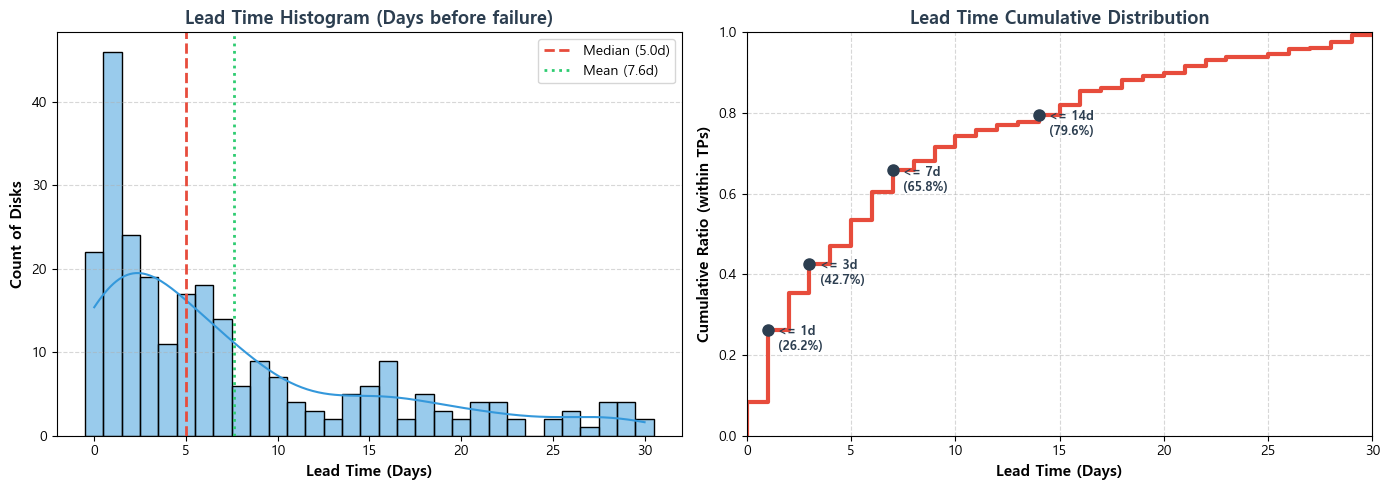

In [4]:
import seaborn as sns
import pandas as pd

# 1. 고장 디스크에 대한 리드타임 추출 (T=0.9590, N=1, Horizon=30)
lead_times = []
horizon = 30
ALARM_WINDOW = 1

for d in disks_data:
    if d['is_failed'] == 1:
        probs = d['probs']
        alarms = (probs >= BEST_T).astype(int)
        rolling = pd.Series(alarms).rolling(window=ALARM_WINDOW, min_periods=1).sum()
        idx = np.where(rolling >= ALARM_WINDOW)[0]
        
        if len(idx) > 0:
            # 알람 발생 시점부터 실제 고장일까지의 일수
            lt = len(probs) - 1 - idx[0]
            if lt <= horizon:
                lead_times.append(lt)

lead_times = np.array(lead_times)
total_failed = n_failed_disks
total_tp = len(lead_times)

print(f"============================================================")
print(f"📊 리드타임(Lead Time) 심층 기술통계 (Horizon: {horizon}일 기준)")
print(f"============================================================")
print(f"  - 전체 고장 디스크 수 : {total_failed:,} 개")
print(f"  - {horizon}일 이내 탐지 성공(TP): {total_tp:,} 개 (Recall: {total_tp/total_failed*100:.2f}%)")
print(f"")
print(f"  [기술통계 요약]")
print(f"    • 평균(Mean)   : {np.mean(lead_times):.2f} 일")
print(f"    • 표준편차(Std): {np.std(lead_times):.2f} 일")
print(f"    • 최소(Min)    : {np.min(lead_times)} 일")
print(f"    • 10% 백분위수 : {np.percentile(lead_times, 10):.1f} 일")
print(f"    • 25% 백분위수 : {np.percentile(lead_times, 25):.1f} 일")
print(f"    • 중앙값(Med)  : {np.median(lead_times):.1f} 일")
print(f"    • 75% 백분위수 : {np.percentile(lead_times, 75):.1f} 일")
print(f"    • 90% 백분위수 : {np.percentile(lead_times, 90):.1f} 일")
print(f"    • 최대(Max)    : {np.max(lead_times)} 일")
print(f"")

print(f"============================================================")
print(f"📈 구간별 누적 탐지 비율 (Cumulative Detection Rate)")
print(f"============================================================")
# 특정 기간 내 탐지된 디스크 비율 (전체 고장 디스크 대비 / TP 대비)
days_thresholds = [0, 1, 3, 5, 7, 10, 14, 21, 30, 40, 60]

print(f"  리드타임 구간 | 탐지 디스크 수 | 탐지 건(TP) 중 비율 | 전체 고장 대비 비율")
print(f"  ------------------------------------------------------------")
for d_th in days_thresholds:
    detected_within = np.sum(lead_times <= d_th)
    ratio_tp = detected_within / total_tp * 100
    ratio_all = detected_within / total_failed * 100
    print(f"   <= {d_th:2d}일 전   | {detected_within:10,} 개 | {ratio_tp:15.1f}% | {ratio_all:16.2f}%")
print(f"============================================================\n")

# 시각화: 히스토그램 및 ECDF (누적 분포 함수)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#ffffff')

# 1. 히스토그램
sns.histplot(lead_times, bins=np.arange(0, horizon+2)-0.5, kde=True, color="#3498db", ax=ax1)
ax1.set_title("Lead Time Histogram (Days before failure)", fontsize=13, fontweight='bold', color='#2c3e50')
ax1.set_xlabel("Lead Time (Days)", fontsize=11, fontweight='bold')
ax1.set_ylabel("Count of Disks", fontsize=11, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.axvline(np.median(lead_times), color='#e74c3c', linestyle='--', lw=2, label=f"Median ({np.median(lead_times):.1f}d)")
ax1.axvline(np.mean(lead_times), color='#2ecc71', linestyle=':', lw=2, label=f"Mean ({np.mean(lead_times):.1f}d)")
ax1.legend()

# 2. 누적 분포(ECDF)
sns.ecdfplot(lead_times, color="#e74c3c", lw=3, ax=ax2)
ax2.set_title("Lead Time Cumulative Distribution", fontsize=13, fontweight='bold', color='#2c3e50')
ax2.set_xlabel("Lead Time (Days)", fontsize=11, fontweight='bold')
ax2.set_ylabel("Cumulative Ratio (within TPs)", fontsize=11, fontweight='bold')
ax2.grid(linestyle='--', alpha=0.5)
ax2.set_xlim(0, horizon)

# ECDF에 주요 마커 표시
for d_th in [1, 3, 7, 14]:
    y_val = np.sum(lead_times <= d_th) / total_tp
    ax2.plot(d_th, y_val, marker='o', markersize=8, color='#2c3e50')
    ax2.text(d_th+0.5, y_val-0.05, f"<= {d_th}d\n({y_val*100:.1f}%)", color='#2c3e50', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


### - 구간별 오탐 분석 및 혼동 행렬 시각화



🚀 Operational Acceptance Boundaries (Horizons: 10, 20, 30, 40, 50 Days)
🚀 최적 운영점(T=0.9590) 30일 리드타임 분포 분석



📊 최적 운영점 평가 결과 (30일 Horizon)
   True Positive (고장 탐지 디스크)  : 260
   False Negative(고장 미탐지 디스크): 867
      - 이 중 알람이 한 번도 안 울린 개체: 709
   False Positive(정상 디스크 오탐)  : 75
   True Negative (정상 디스크 정상)  : 6,180
   Recall (Hit Rate) : 23.07%
   FAR (오탐율)      : 1.20%
   Precision         : 77.61%

📈 리드타임(Lead Time) 통계치
   Mean   : 7.7 일
   25th   : 1.0 일
   Median : 5.0 일
   75th   : 11.0 일
   IQR    : 10.0 일


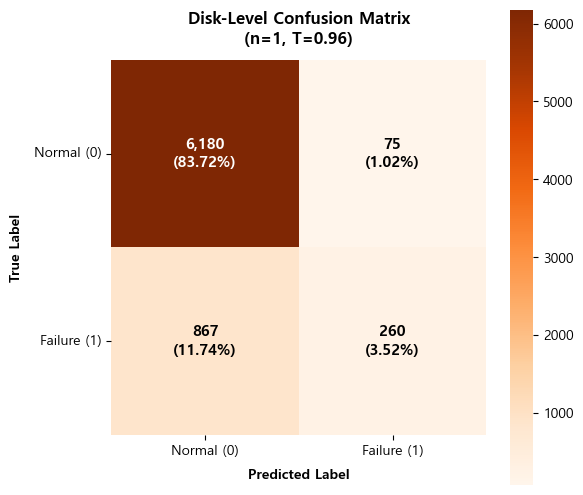

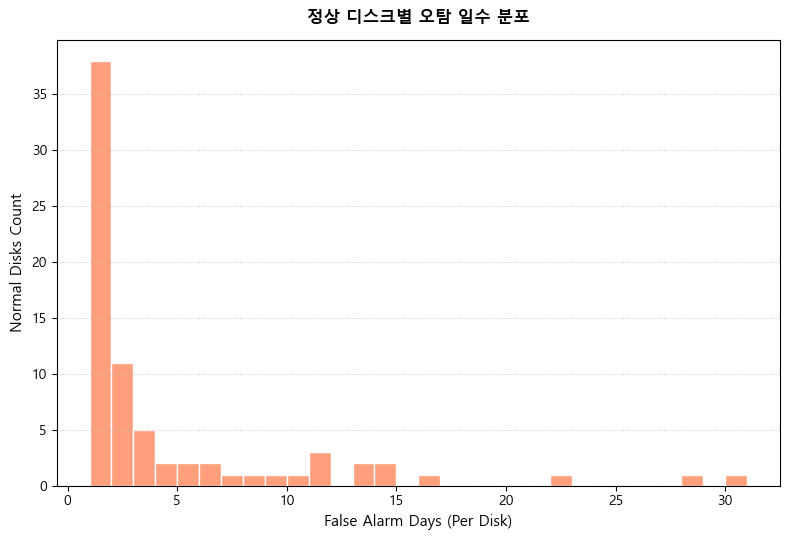

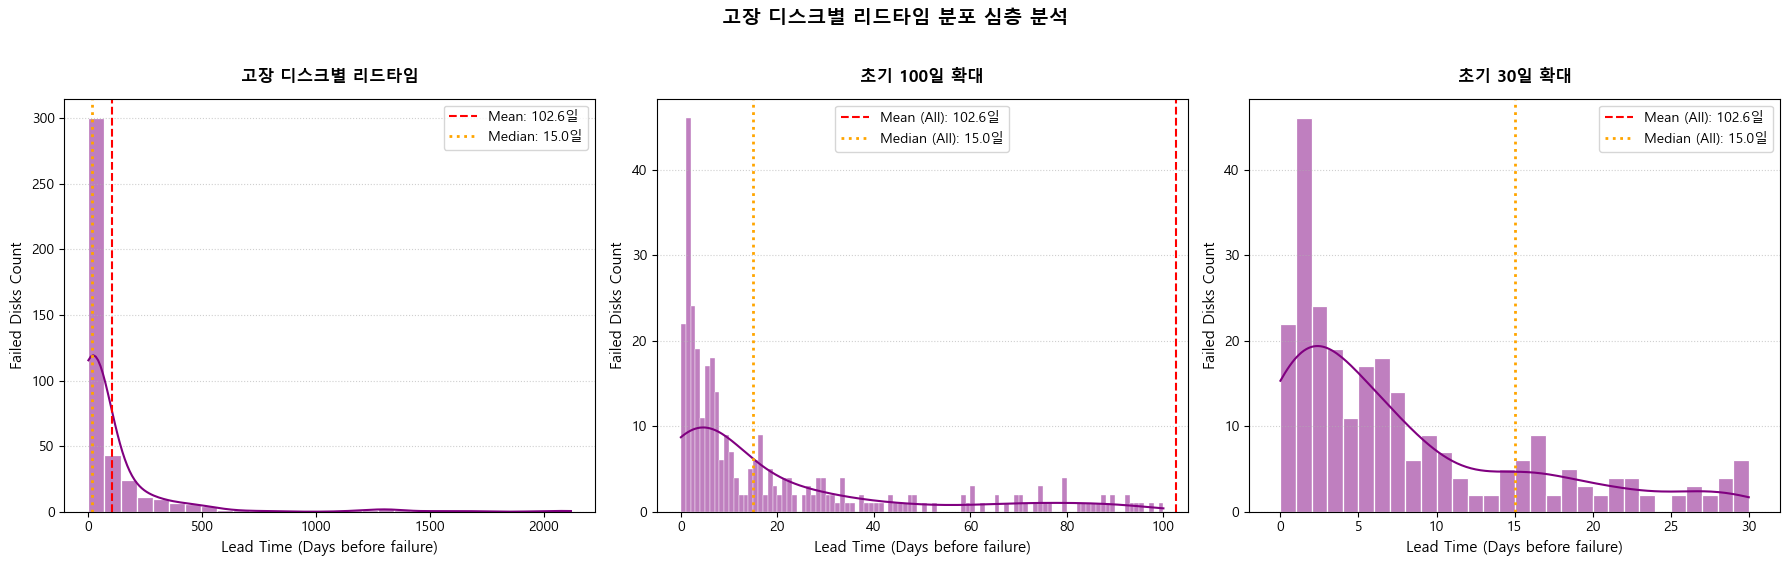

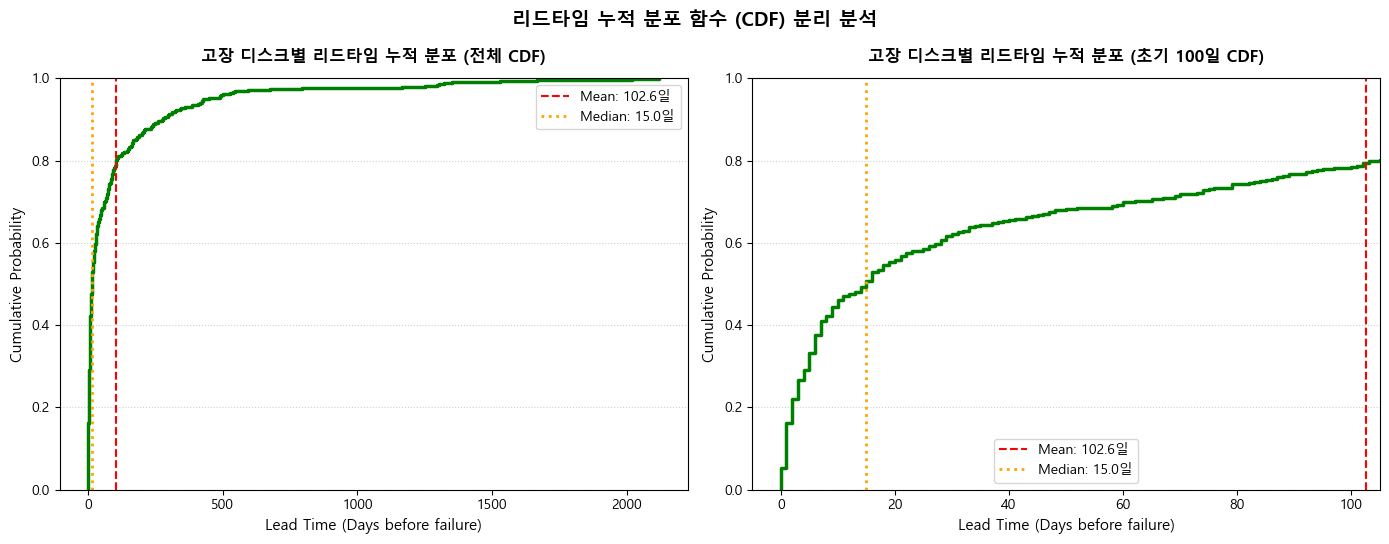


🚀 Operational Acceptance Boundaries (Horizons: 1000, 20, 30, 40, 50 Days)


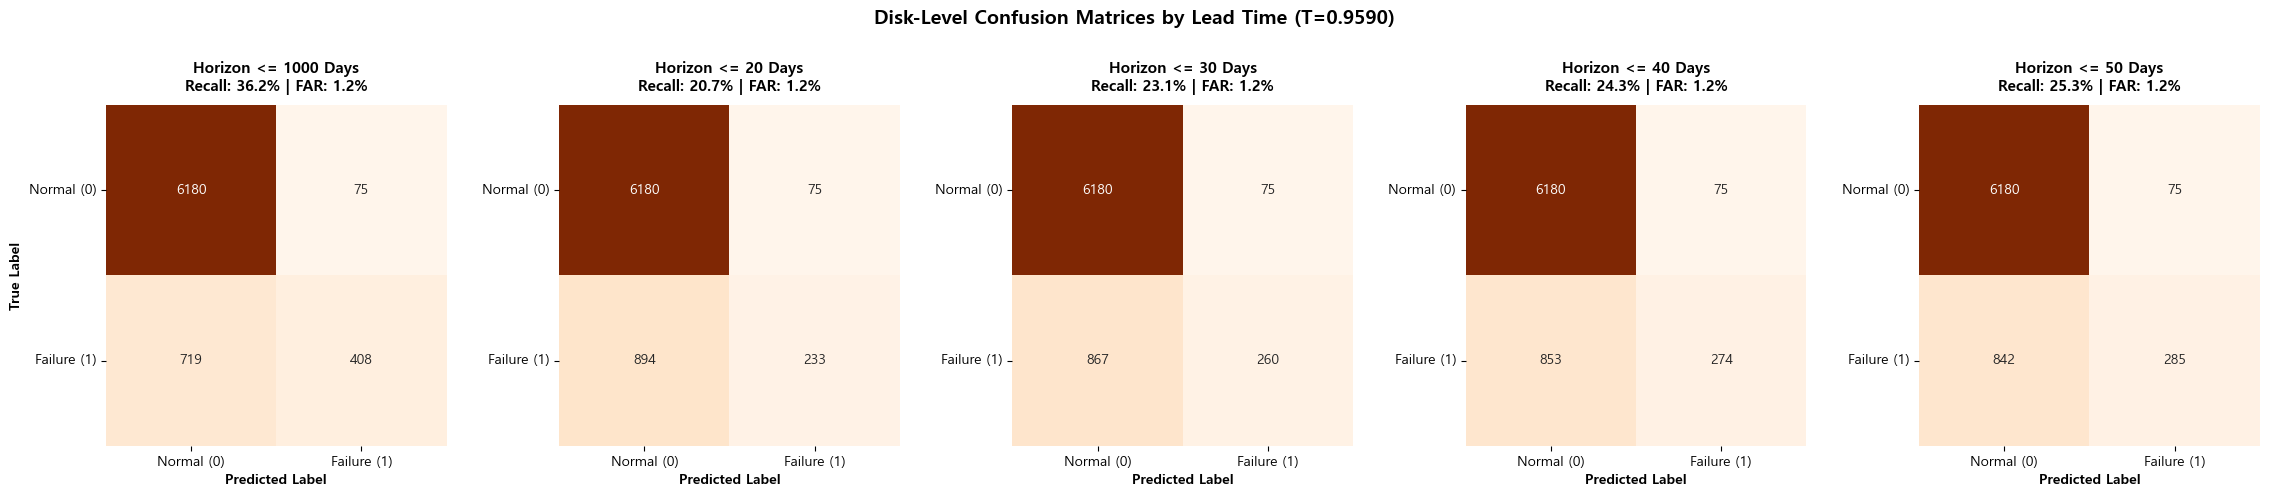

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import importlib
import src.eval_core
importlib.reload(src.eval_core)
from src.eval_core import plot_detailed_disk_analysis
print("\n" + "="*70)
horizons = [10, 20, 30, 40, 50] # 원하는 리드타임(Horizon)을 리스트에 입력하세요
print(f"🚀 Operational Acceptance Boundaries (Horizons: {', '.join(map(str, horizons))} Days)")
print(f"🚀 최적 운영점(T={BEST_T:.4f}) 30일 리드타임 분포 분석")
print("="*70)

best_disk_records = []
for disk in disks_data:
    probs = disk['probs']
    y_pred = (probs >= BEST_T).astype(int)
    total_alarms = y_pred.sum()
    
    is_valid_trigger = (y_pred == 1)
        
    lead_time = np.nan
    is_alarmed = 0
    
    if disk['is_failed'] == 1:
        dates = pd.Series(pd.to_datetime(disk['dates']))
        last_date = dates.iloc[-1]
        days_to_fail = (last_date - dates).dt.days
        
        # 고장 이전 모든 알람 중 첫 알람의 Lead Time
        valid_alarms = is_valid_trigger
        if valid_alarms.any():
            trigger_idx = np.where(valid_alarms)[0][0]
            trigger_date = dates.iloc[trigger_idx]
            lead_time = (last_date - trigger_date).days
            is_alarmed = 1
    else:
        if is_valid_trigger.any():
            is_alarmed = 1
            
    best_disk_records.append({
        'base_serial': disk['base_serial'],
        'is_failed': disk['is_failed'],
        'is_alarmed': is_alarmed,
        'total_alarms': total_alarms,
        'lead_time': lead_time,
    })
    
df_best_disk = pd.DataFrame(best_disk_records)

# 3. 혼동행렬 구성
tp = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 1) & (df_best_disk['lead_time'] <= 30)).sum())
fn = n_failed_disks - tp
fp = int(((df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 1)).sum())
tn = int(((df_best_disk['is_failed'] == 0) & (df_best_disk['is_alarmed'] == 0)).sum())

# 4. 시각화 출력 (src.eval_core 의 plot 함수 재활용)
print(f"\n📊 최적 운영점 평가 결과 (30일 Horizon)")
print(f"   True Positive (고장 탐지 디스크)  : {tp:,}")
print(f"   False Negative(고장 미탐지 디스크): {fn:,}")
no_alarm_fn = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 0)).sum())
print(f"      - 이 중 알람이 한 번도 안 울린 개체: {no_alarm_fn:,}")
print(f"   False Positive(정상 디스크 오탐)  : {fp:,}")
print(f"   True Negative (정상 디스크 정상)  : {tn:,}")
print(f"   Recall (Hit Rate) : {tp/n_failed_disks*100:.2f}%")
print(f"   FAR (오탐율)      : {fp/n_normal_disks*100:.2f}%")
if (tp + fp) > 0:
    print(f"   Precision         : {tp/(tp+fp)*100:.2f}%")

df_lt = df_best_disk[(df_best_disk['lead_time'].notna()) & (df_best_disk['lead_time'] <= 30)]['lead_time']
if len(df_lt) > 0:
    print("\n📈 리드타임(Lead Time) 통계치")
    print(f"   Mean   : {df_lt.mean():.1f} 일")
    print(f"   25th   : {df_lt.quantile(0.25):.1f} 일")
    print(f"   Median : {df_lt.median():.1f} 일")
    print(f"   75th   : {df_lt.quantile(0.75):.1f} 일")
    print(f"   IQR    : {df_lt.quantile(0.75) - df_lt.quantile(0.25):.1f} 일")

# 혼동행렬 및 분포 시각화 (stats_orig 활용)
plot_detailed_disk_analysis(stats_orig, df_best_disk, tp, fn, fp, tn)

# 5. 다중 리드타임 혼동행렬 이어서 출력
print("\n" + "="*70)
horizons = [1000, 20, 30, 40, 50] # 원하는 리드타임(Horizon)을 리스트에 입력하세요
print(f"🚀 Operational Acceptance Boundaries (Horizons: {', '.join(map(str, horizons))} Days)")
print("="*70)

n_horizons = len(horizons)
fig, axes = plt.subplots(1, n_horizons, figsize=(4.6 * n_horizons, 4.5))
if n_horizons == 1:
    axes = [axes]
for i, horizon in enumerate(horizons):
    tp_h = int(((df_best_disk['is_failed'] == 1) & (df_best_disk['is_alarmed'] == 1) & (df_best_disk['lead_time'] <= horizon)).sum())
    fn_h = n_failed_disks - tp_h
    fp_h = fp
    tn_h = tn
    cm_disk = np.array([[tn_h, fp_h], [fn_h, tp_h]])
    sns.heatmap(cm_disk, annot=True, fmt="d", cmap="Oranges", cbar=False, square=True, ax=axes[i])
    axes[i].set_xticks([0.5, 1.5])
    axes[i].set_xticklabels(["Normal (0)", "Failure (1)"])
    axes[i].set_yticks([0.5, 1.5])
    axes[i].set_yticklabels(["Normal (0)", "Failure (1)"], rotation=0)
    axes[i].set_xlabel("Predicted Label", fontweight="bold")
    if i == 0:
        axes[i].set_ylabel("True Label", fontweight="bold")
    axes[i].set_title(f"Horizon <= {horizon} Days\nRecall: {tp_h/n_failed_disks*100:.1f}% | FAR: {fp_h/n_normal_disks*100:.1f}%", fontsize=11, fontweight="bold", pad=10)

plt.suptitle(f"Disk-Level Confusion Matrices by Lead Time (T={BEST_T:.4f})", fontsize=14, fontweight="bold", y=1.05)
plt.tight_layout()
plt.show()


## 6. 오탐 분석의 다각화: 정상 개체 순수 오탐 vs 고장 개체 조기 오탐

현실적인 데이터 센터 환경에서 "정상 디스크" 역시 관측 기간 이후 결국 고장날 수 있으므로, 두 상태를 결정론적으로 이분하는 것은 분석의 한계를 낳을 수 있습니다. 
따라서 고장 디스크(`is_failed == 1`) 중 **유지보수 목표 기간(30일)보다 훨씬 이른 시점(> 30일 전)에 경보가 울린 조기 오탐(Early Alarm)**의 분포를 시각화하여 순수 오탐(정상 개체) 분포와 나란히 비교합니다.

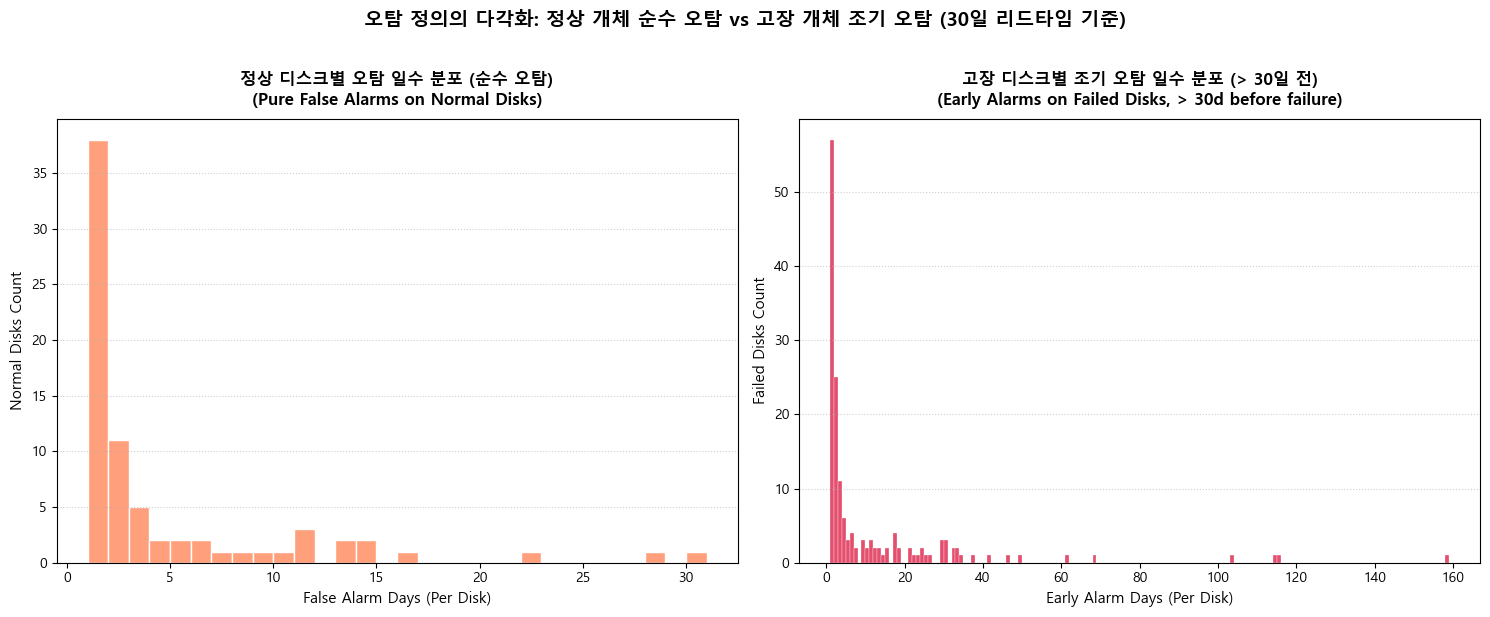

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# 1. 0.9590 기준의 df_best_disk 구성 (노트북 독립성 보장)
t_val = 0.9590
best_disk_records = []
for disk in disks_data:
    probs = disk['probs']
    y_pred = (probs >= t_val).astype(int)
    total_alarms = y_pred.sum()
    
    lead_time = np.nan
    is_alarmed = 0
    
    if disk['is_failed'] == 1:
        dates = pd.Series(pd.to_datetime(disk['dates']))
        last_date = dates.iloc[-1]
        days_to_fail = (last_date - dates).dt.days
        
        # 고장 이전 모든 알람 중 첫 번째 알람의 Lead Time
        if y_pred.any():
            trigger_idx = np.where(y_pred == 1)[0][0]
            trigger_date = dates.iloc[trigger_idx]
            lead_time = (last_date - trigger_date).days
            is_alarmed = 1
    else:
        if y_pred.any():
            is_alarmed = 1
            
    best_disk_records.append({
        'base_serial': disk['base_serial'],
        'is_failed': disk['is_failed'],
        'is_alarmed': is_alarmed,
        'total_alarms': total_alarms,
        'lead_time': lead_time,
    })
    
df_best_disk_local = pd.DataFrame(best_disk_records)

# 2. 정상 디스크의 오탐 일수 (Pure False Alarms)
normal_fa_days = df_best_disk_local[(df_best_disk_local["is_failed"] == 0) & (df_best_disk_local["total_alarms"] > 0)]["total_alarms"]

# 3. 고장 디스크의 조기 오탐 일수 (>30일 전 알람 일수)
early_fa_days = []
for d in disks_data:
    if d['is_failed'] == 1:
        probs = d['probs']
        y_pred = (probs >= t_val).astype(int)
        dates = pd.Series(pd.to_datetime(d['dates']))
        last_date = dates.iloc[-1]
        days_to_fail = (last_date - dates).dt.days
        
        # 고장 30일 초과 전에 발생한 알람 일수 합산
        early_count = np.sum(y_pred[days_to_fail > 30])
        if early_count > 0:
            early_fa_days.append(early_count)

early_fa_days = pd.Series(early_fa_days)

# 4. 한국어 폰트 설정
import matplotlib.font_manager as fm
for name in ["Malgun Gothic", "NanumGothic", "AppleGothic", "DejaVu Sans"]:
    if any(name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
        plt.rcParams["font.family"] = name
        break
plt.rcParams["axes.unicode_minus"] = False

# 5. 시각화: Side-by-Side 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor('#ffffff')

# Left: 정상 디스크 오탐
sns.histplot(normal_fa_days, binwidth=1, kde=False, color="coral", edgecolor="white", ax=ax1)
ax1.set_title("정상 디스크별 오탐 일수 분포 (순수 오탐)\n(Pure False Alarms on Normal Disks)", fontsize=12, fontweight="bold", pad=10)
ax1.set_xlabel("False Alarm Days (Per Disk)", fontsize=11)
ax1.set_ylabel("Normal Disks Count", fontsize=11)
ax1.grid(axis="y", linestyle=":", alpha=0.6)

# Right: 고장 디스크 조기 오탐 (> 30일 전)
if len(early_fa_days) > 0:
    sns.histplot(early_fa_days, binwidth=1, kde=False, color="crimson", edgecolor="white", ax=ax2)
    ax2.set_title("고장 디스크별 조기 오탐 일수 분포 (> 30일 전)\n(Early Alarms on Failed Disks, > 30d before failure)", fontsize=12, fontweight="bold", pad=10)
    ax2.set_xlabel("Early Alarm Days (Per Disk)", fontsize=11)
    ax2.set_ylabel("Failed Disks Count", fontsize=11)
    ax2.grid(axis="y", linestyle=":", alpha=0.6)
else:
    ax2.text(0.5, 0.5, "조기 경보가 발생한 고장 개체가 없습니다.", ha="center", va="center", transform=ax2.transAxes)

plt.suptitle("오탐 정의의 다각화: 정상 개체 순수 오탐 vs 고장 개체 조기 오탐 (30일 리드타임 기준)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
